<a href="https://colab.research.google.com/github/Madinsh/project/blob/main/Project_programming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#PARSING of the main website-detskiy mir

import requests
from bs4 import BeautifulSoup
import pandas as pd
import random
import time

BASE = "https://detmir.kz/"

#checking for the website's robots text
robots_url=BASE+"/robots.txt"
robots=requests.get(robots_url)
print("ROBOTS TXT")
print(robots.text)

ROBOTS TXT
User-agent: Yandex
Disallow: /catalog/*kz_action/*
Disallow: */id/*/questions
Disallow: */is_sale/1/brand/
Disallow: /search/results/
Disallow: /admin/
Disallow: */name/*/*/*/*page*
Disallow: *_kz_*
Disallow: /basket/
Disallow: /feedback/
Disallow: /auth/
Disallow: /profile/
Disallow: /*order/
Disallow: /*per_page/
Disallow: /*is_present
Disallow: /*?
Allow: /*?page
Disallow: /*/nojs/*/
Disallow: /page/
Disallow: *categories-*
Disallow: /*price
Disallow: */gender
Disallow: */bigsale
Disallow: *.pdf
Disallow: /news
Disallow: /pages/rules/$
Disallow: *_cyber19_kz*
Disallow: *_cyber20_kz*
Disallow: */page/*/*/
Allow: /*.jpg 
Allow: /*.css 
Allow: /*.js 
Allow: /*.png 
Allow: /*.ico 
Allow: /*.ttf 
Allow: /*.woff 
Allow: /*.woff2 
Allow: /*.webp 
Allow: /media/
Clean-param: variant_id&order&filter&cumulative_discount&order&site&amp&clear&erid&utm_campaign&utm_content&utm_medium&utm_source&utm_term&yclid

User-agent: Googlebot
Disallow: /catalog/*kz_action/*
Disallow: */id/*/ques

In [ ]:
#adding headers to lower the risk of getting blocked by the website
headers = {
    "User-Agent": "SDS-106 Dream Team's Project Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Safari/537.36"
}

#categories of items for parsing
categories = {
    "clothing": "https://detmir.kz/catalog/index/name/children_clothes/",
    "foot wear": "https://detmir.kz/catalog/index/name/detskaya_obuv/",
    "baby food & feeding": "https://detmir.kz/catalog/index/name/nutrition_feeding/",
    "toys": "https://detmir.kz/catalog/index/name/igry_i_igrushki/",
    "hobby": "https://detmir.kz/catalog/index/name/hobbies_creativity/",
    "books": "https://detmir.kz/catalog/index/name/knigy/",
    "care & hygiene": "https://detmir.kz/catalog/index/name/hygiene_care/"
}

data = []

#MAIN LOOP OF CATEGORIES
for category_name, url in categories.items():
    category_count = 0
    seen_products = set()

    #pagination
    for page in range(1, 100):
        if category_count >= 900:
            break

        page_url = url + "?page=" + str(page)
        response = None

        #request with retries
        for attempt in range(3):
            try:
                response = requests.get(page_url, headers=headers)
                if response.status_code == 200:
                  break
                else:
                    time.sleep(random.uniform(1, 2))
            except requests.exceptions.RequestException:
                time.sleep(random.uniform(1, 2))

        #when the website doesn't allow parsing
        if response is None:
            print(f"Error: no response for {category_name}, page {page}")
            continue

        if response.status_code != 200:
            print(f"Error {response.status_code}: {category_name}, page {page}")
            continue

        #parsing HTML code
        soup = BeautifulSoup(response.text, "html.parser")

        #parsing items with class new-product
        sections = soup.find_all("section", attrs={"data-product-id": True})

        if len(sections) == 0:
            print(f"No more products in category: {category_name}")
            break

        #parsing information about products in the cards
        for section in sections:
            if category_count >= 900:
                break

            try:
                #product ID
                product_id=section.get("data-product-id")

                #rating
                rating_tag=section.find("span", attrs={"data-testid":"rating"})
                rating=rating_tag.find("span", attrs={"data-testid":"typography"}).text.strip()

                #reviews
                reviews_tag=section.find("span", attrs={"data-testid": "reviewCount"})
                reviews=reviews_tag.text

                #product name
                name_tag=section.find("a", attrs={"data-testid":"titleLink"})
                product_name=name_tag.find("span")
                name=product_name.text.strip()

                #price
                price_section=section.find("div", attrs={"data-testid":"productPrice"})
                price_block=price_section.find("div", class_="SBnIi")
                current_price=None
                old_price=None
                if price_block:
                  price_values=[]
                  for span in price_block.find_all("span"):
                    text=span.get_text(" ", strip=True)
                    price_values.append(text)
                    if len(price_values)>=1:
                      current_price=price_values[0]
                    if len(price_values)>=2:
                      old_price=price_values[1]

                #link
                product_link=section.find("a").get("href")
                res=requests.get(product_link, headers=headers)
                prod_soup=BeautifulSoup(res.text, "html.parser")

                #find all rows in the table
                for row in prod_soup.find_all("tr", attrs={"data-testid": "characteristicRow"}):
                  spans = row.find_all("span")
                  if len(spans) >= 2:
                    label = spans[0].get_text(strip=True)
                    value = spans[1].get_text(strip=True)
                    if "Страна производства" in label:
                      country = value
                      break
                #save data to the list
                data.append({
                    "Name": name,
                    "Current Price": current_price,
                    "Old Price": old_price,
                    "Rating": rating,
                    "Review Count": reviews,
                    "Product Code": product_id,
                    "Category": category_name,
                    "Link": product_link,
                    "Country of Manufacture": country
                })
                category_count += 1

            except Exception:
                continue

        print(f"Category: {category_name}, page: {page}, collected: {category_count}")

        #small pause between pages
        time.sleep(random.uniform(1, 2))

    print(f"Finished category '{category_name}' with exactly {category_count} items.")

    #pause between categories in order to prevent getting banned
    time.sleep(random.uniform(1, 2))

#creating DataFrame & saving CSV file
df = pd.DataFrame(data)
df.to_csv("raw_data_detskiy_mir.csv", index=False, encoding="utf-8-sig")
print(df["Category"].value_counts())
print(df.head(20))

Category: clothing, page: 1, collected: 4
Category: clothing, page: 2, collected: 15
Category: clothing, page: 3, collected: 32
Category: clothing, page: 4, collected: 53
Category: clothing, page: 5, collected: 71
Category: clothing, page: 6, collected: 84
Category: clothing, page: 7, collected: 106
Category: clothing, page: 8, collected: 142
Category: clothing, page: 9, collected: 177
Category: clothing, page: 10, collected: 200
Category: clothing, page: 11, collected: 224
Category: clothing, page: 12, collected: 250
Category: clothing, page: 13, collected: 274
Category: clothing, page: 14, collected: 298
Category: clothing, page: 15, collected: 322
Category: clothing, page: 16, collected: 350
Category: clothing, page: 17, collected: 374
Category: clothing, page: 18, collected: 396
Category: clothing, page: 19, collected: 410
Category: clothing, page: 20, collected: 443
Category: clothing, page: 21, collected: 462
Category: clothing, page: 22, collected: 487
Category: clothing, page: 

In [9]:
# Phase 2: Data cleaning and transformation
# Cleaning of website detskiy mir
import numpy as np
import pandas as pd

df = pd.read_csv("raw_data_detskiy_mir.csv")
print(df.head())
print(df.info())

                       Name Current Price Old Price Rating Review Count  \
0  Майки Day and Night 2 шт       2 499 ₸   4 999 ₸      5         223    
1           Жилет Chessford       1 999 ₸   6 999 ₸    4,9         202    
2         Комбинезон BabyGо       1 499 ₸   2 999 ₸    4,7         221    
3           Платье Futurino       3 999 ₸   7 999 ₸      5          50    
4            Брюки Futurino       3 499 ₸   6 999 ₸    4,9         145    

   Product Code  Category                                         Link  \
0       6691045  clothing  https://detmir.kz/product/index/id/6691045/   
1       6635615  clothing  https://detmir.kz/product/index/id/6635615/   
2       6690919  clothing  https://detmir.kz/product/index/id/6690919/   
3       6669905  clothing  https://detmir.kz/product/index/id/6669905/   
4       6690881  clothing  https://detmir.kz/product/index/id/6690881/   

  Country of Manufacture  
0                  Китай  
1              Бангладеш  
2                  Кита

In [10]:
print(df.isnull().sum())

Name                         0
Current Price                0
Old Price                 1119
Rating                       0
Review Count                 0
Product Code                 0
Category                     0
Link                         0
Country of Manufacture       0
dtype: int64


In [11]:
# Convert ratings from text to numbers
df['Rating'] = df['Rating'].astype(str).str.replace(',', '.')
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

In [12]:
# Count unique links and product codes
print(f"Unique Links: {df['Link'].nunique()}")
print(f"Unique Product Codes: {df['Product Code'].nunique()}")
print(f"Total Rows: {len(df)}")

Unique Links: 810
Unique Product Codes: 810
Total Rows: 4200


In [13]:
# Remove duplicate links first
df = df.drop_duplicates(subset=['Link'], keep='first')

# Remove rows where BOTH product name and product code are the same
df = df.drop_duplicates(subset=['Name', 'Product Code'], keep='first')

# Reset index so there are no gaps in the row numbers
df = df.reset_index(drop=True)

In [14]:
# Count unique links and product codes
print(f"Unique Links: {df['Link'].nunique()}")
print(f"Unique Product Codes: {df['Product Code'].nunique()}")
print(f"Total Rows: {len(df)}")

Unique Links: 810
Unique Product Codes: 810
Total Rows: 810


In [15]:
import re

# Cleaning of prices
def extract_digits(value):
  if pd.isna(value):
    return np.nan
  str_value = str(value)
  digits = re.sub(r'\D', '', str_value)
  return float(digits) if digits else np.nan

# Cleaning of column "Review Count"
df['Review Count'] = df['Review Count'].apply(extract_digits)
df['Current Price'] = df['Current Price'].apply(extract_digits)
df['Old Price'] = df['Old Price'].apply(extract_digits).fillna(0)

# Debugging print statement before dropna
print("DataFrame head before dropna:")
print(df[['Current Price', 'Review Count']].head())
print("Number of NaNs in 'Current Price' before dropna:", df['Current Price'].isna().sum())
print("Number of NaNs in 'Review Count' before dropna:", df['Review Count'].isna().sum())

df.dropna(subset = ['Current Price', 'Review Count'], inplace = True)

DataFrame head before dropna:
   Current Price  Review Count
0         2499.0         223.0
1         1999.0         202.0
2         1499.0         221.0
3         3999.0          50.0
4         3499.0         145.0
Number of NaNs in 'Current Price' before dropna: 0
Number of NaNs in 'Review Count' before dropna: 0


In [16]:
df['Current Price'] = df['Current Price'].astype(int)
df['Old Price'] = df['Old Price'].astype(int)
df['Review Count'] = df['Review Count'].astype(int)

# Remove duplicate product codes
df.drop_duplicates(subset=['Product Code'], inplace=True)

print("DataFrame after type conversion and duplicate removal:")
print(df.info())
display(df.head())

DataFrame after type conversion and duplicate removal:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 810 entries, 0 to 809
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    810 non-null    object 
 1   Current Price           810 non-null    int64  
 2   Old Price               810 non-null    int64  
 3   Rating                  810 non-null    float64
 4   Review Count            810 non-null    int64  
 5   Product Code            810 non-null    int64  
 6   Category                810 non-null    object 
 7   Link                    810 non-null    object 
 8   Country of Manufacture  810 non-null    object 
dtypes: float64(1), int64(4), object(4)
memory usage: 57.1+ KB
None


,Name,Current Price,Old Price,Rating,Review Count,Product Code,Category,Link,Country of Manufacture
0,Майки Day and Night 2 шт,2499,4999,5.0,223,6691045,clothing,https://detmir.kz/product/index/id/6691045/,Китай
1,Жилет Chessford,1999,6999,4.9,202,6635615,clothing,https://detmir.kz/product/index/id/6635615/,Бангладеш
2,Комбинезон BabyGо,1499,2999,4.7,221,6690919,clothing,https://detmir.kz/product/index/id/6690919/,Китай
3,Платье Futurino,3999,7999,5.0,50,6669905,clothing,https://detmir.kz/product/index/id/6669905/,Китай
4,Брюки Futurino,3499,6999,4.9,145,6690881,clothing,https://detmir.kz/product/index/id/6690881/,Китай


In [17]:
# Normalization
if 'Name' in df.columns:
  df.loc[:, 'Name'] = df['Name'].str.lower().str.strip()

# Outliers
if not df['Current Price'].dropna().empty and len(df['Current Price'].dropna().unique()) > 1:
    Q1 = df['Current Price'].quantile(0.25)
    Q3 = df['Current Price'].quantile(0.75)

    if pd.notna(Q1) and pd.notna(Q3):
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df = df[(df['Current Price'] >= lower_bound) & (df['Current Price'] <= upper_bound)]
    else:
        print("Skipping outlier removal for 'Current Price' due to NaN quantiles.")
else:
    print("Skipping outlier removal for 'Current Price' due to insufficient data or all NaN values.")

In [18]:
# Feature Engineering
# Discount percentile:
df['discount_percentile'] = np.where(
    df['Old Price'] > 0,
    ((df['Old Price'] - df['Current Price']) / df['Old Price'] * 100).round(2),
    0
)

# Value for money
df['value_for_money'] = (df['Review Count'] / df['Current Price']).round(4)

# Price bucket
df['price_bucket'] = pd.qcut(df['Current Price'], q = 3, labels = ['low', 'medium', 'high'])

In [19]:
# Deleting duplicates and exporting
df.drop_duplicates(inplace = True)
df.to_csv('cleaned_data_detskiy_mir.csv', index = False)

print("Cleaning completed")
print(f"The final number of rows: {len(df)}")
print(df.head())

Cleaning completed
The final number of rows: 747
                       Name  Current Price  Old Price  Rating  Review Count  \
0  майки day and night 2 шт           2499       4999     5.0           223   
1           жилет chessford           1999       6999     4.9           202   
2         комбинезон babygо           1499       2999     4.7           221   
3           платье futurino           3999       7999     5.0            50   
4            брюки futurino           3499       6999     4.9           145   

   Product Code  Category                                         Link  \
0       6691045  clothing  https://detmir.kz/product/index/id/6691045/   
1       6635615  clothing  https://detmir.kz/product/index/id/6635615/   
2       6690919  clothing  https://detmir.kz/product/index/id/6690919/   
3       6669905  clothing  https://detmir.kz/product/index/id/6669905/   
4       6690881  clothing  https://detmir.kz/product/index/id/6690881/   

  Country of Manufacture  disco

In [54]:
#Phase 3: Exploratory Data Analysis (EDA)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Loading cleaned datasets
df_detmir = pd.read_csv('cleaned_data_detskiy_mir.csv')
df_flip = pd.read_csv('cleaned_data_flip_kz.csv')

# Adding source labels for cross-source comparison
df_detmir['source'] = 'Detskiy Mir'
df_flip['source'] = 'Flip.kz'

# Combine into a single DataFrame for easier multi-source visualization
df = pd.concat([df_detmir, df_flip], ignore_index=True)


In [55]:
# 1. Descriptive statistics
print("\n 1. Descriptive statistics")

# Group by 'source'
stats = df_detmir.groupby('source')[['Current Price', 'Review Count', 'Rating', 'discount_percentile']].describe().T
print(stats)

#Mode
print("\nMode")
modes = df_detmir.groupby('source')[['Current Price', 'Review Count', 'Rating']].agg(lambda x: x.mode().iloc[0])
print(modes)


 1. Descriptive statistics
source                      Detskiy Mir
Current Price       count   5231.000000
                    mean    3933.723189
                    std     3354.016901
                    min       29.000000
                    25%     1290.000000
                    50%     2799.000000
                    75%     5999.000000
                    max    14749.000000
Review Count        count   5231.000000
                    mean     185.783215
                    std      518.006497
                    min        1.000000
                    25%        8.000000
                    50%       32.000000
                    75%      131.500000
                    max    14084.000000
Rating              count   5231.000000
                    mean       4.816574
                    std        0.311154
                    min        1.000000
                    25%        4.800000
                    50%        4.900000
                    75%        5.000000
            

In [56]:
# 2. Analyze distributions (Skewness)
print("\nChecking if prices are normally distributed")

# Check for normal distribution in pricing.
print(df_detmir.groupby('source')['Current Price'].skew())
print("""\nRight-Skewed: Detskiy Mir store have a "long tail" of high-priced items, meaning most products are relatively cheap.
\nDetskiy Mir (0.95): Moderately skewed. More balanced than Flip, but still biased toward lower price points.""")


Checking if prices are normally distributed
source
Detskiy Mir    1.070289
Name: Current Price, dtype: float64

Right-Skewed: Detskiy Mir store have a "long tail" of high-priced items, meaning most products are relatively cheap.

Detskiy Mir (0.95): Moderately skewed. More balanced than Flip, but still biased toward lower price points.


In [57]:
# 3. Correlation analysis
print(" 3. Correlation Matrix: Detskiy mir")
numeric_cols = ['Current Price', 'Review Count', 'Rating', 'discount_percentile']
correlation = df_detmir[numeric_cols].corr()
print(correlation)

 3. Correlation Matrix: Detskiy mir
                     Current Price  Review Count    Rating  \
Current Price             1.000000      0.046152 -0.095205   
Review Count              0.046152      1.000000  0.042680   
Rating                   -0.095205      0.042680  1.000000   
discount_percentile       0.050092      0.078498 -0.060154   

                     discount_percentile  
Current Price                   0.050092  
Review Count                    0.078498  
Rating                         -0.060154  
discount_percentile             1.000000  


In [58]:
# 4. Group-by analysis
print("\n 4. Group-by analysis (Mean Price by Category): Detskiy mir")

# Sorting by Current Price to highlight the most expensive categories
category_stats = df_detmir.groupby('Category')[['Current Price', 'Rating']].mean().sort_values(by='Current Price', ascending=False)
print(category_stats)


 4. Group-by analysis (Mean Price by Category): Detskiy mir
                     Current Price    Rating
Category                                    
toys                   7175.057971  4.775942
foot wear              6326.891156  4.842857
clothing               4788.040223  4.799553
hobby                  3341.311538  4.766026
care & hygiene         3314.333748  4.827895
baby food & feeding    2552.567506  4.853776
books                  2215.125140  4.853855


In [59]:
# 5. Top-N and Bottom-N records

# Top 5 Most Expensive Products
print("\n Top 5 Most Expensive Products (Detskiy mir)")
top_expensive = df_detmir.nlargest(5, 'Current Price')[['Name', 'Current Price', 'Category', 'source']]
print(top_expensive)

# Bottom 5 Cheapest Products
print("\n Bottom 5 Cheapest Products (Detskiy mir)")
bottom_cheap = df_detmir.nsmallest(5, 'Current Price')[['Name', 'Current Price', 'Category', 'source']]
print(bottom_cheap)

# Top 5 Most Popular Products (By Review Count)
print("\n Top 5 Most Popular Products (By Review Count) (Detskiy mir)")
top_popular = df_detmir.nlargest(5, 'Review Count')[['Name', 'Review Count', 'Rating', 'source']]
print(top_popular)


 Top 5 Most Expensive Products (Detskiy mir)
                                                  Name  Current Price  \
1326  смесь молочная similac комфорт 1 750г с 0месяцев          14749   
2452                            автомобиль ру mobicaro          14690   
3334               аквамозаика aquabeads волшебный мир          14690   
2094                кукла модельная demi star праздник          14590   
2132          кукла модельная demi star семейный досуг          14590   

                 Category       source  
1326  baby food & feeding  Detskiy Mir  
2452                 toys  Detskiy Mir  
3334                hobby  Detskiy Mir  
2094                 toys  Detskiy Mir  
2132                 toys  Detskiy Mir  

 Bottom 5 Cheapest Products (Detskiy mir)
                                       Name  Current Price        Category  \
3120  карандаши чернографитные erhaft 1 шт.             29           hobby   
3121  карандаши чернографитные erhaft 1 шт.             55           h

In [60]:
# 6. Analytical Hypotheses

# Hypothesis 1: Products with higher discounts attract more customer reviews
print("\nHypothesis 1: Products with higher discounts attract more customer reviews")

# Compare mean reviews for discounted vs. non-discounted products
h1_disc = df[df['discount_percentile'] > 0]['Review Count'].mean()
h1_nodisc = df[df['discount_percentile'] == 0]['Review Count'].mean()
print(f"\nDiscounted avg reviews: {h1_disc:.2f} vs Non-discounted: {h1_nodisc:.2f}")
if h1_disc > h1_nodisc:
    print("CONCLUSION: Hypothesis CONFIRMED. Discounts are a major driver of customer activity.")
else:
    print("CONCLUSION: Hypothesis REJECTED. Discounts do not significantly affect popularity.")

# Sub Hypothesis: Products with discounts > 50% have significantly lower ratings than products with < 10% discounts (suggesting clearance of unpopular stock).
print("\nSub Hypothesis: Discount-Quality Relationship")

# Check if deep discounts (>50%) correlate with lower ratings
high_disc_rating = df_detmir[df_detmir['discount_percentile'] > 50]['Rating'].mean()
low_disc_rating = df_detmir[df_detmir['discount_percentile'] < 10]['Rating'].mean()

print(f"\nAvg Rating (>50% discount): {high_disc_rating:.2f}")
print(f"Avg Rating (<10% discount): {low_disc_rating:.2f}")

# Result and Conclusion
if high_disc_rating < (low_disc_rating - 0.2): # 0.2 threshold for significance
    print("CONCLUSION: Hypothesis CONFIRMED. Deep discounts are likely used for unpopular stock clearance.")
else:
    print("CONCLUSION: Hypothesis REJECTED. High discounts do not necessarily mean lower quality.")


Hypothesis 1: Products with higher discounts attract more customer reviews

Discounted avg reviews: 178.39 vs Non-discounted: 89.87
CONCLUSION: Hypothesis CONFIRMED. Discounts are a major driver of customer activity.

Sub Hypothesis: Discount-Quality Relationship

Avg Rating (>50% discount): 4.77
Avg Rating (<10% discount): 4.83
CONCLUSION: Hypothesis REJECTED. High discounts do not necessarily mean lower quality.


In [61]:
# checking unique countries
print(df_detmir['Country of Manufacture'].unique())


['Китай' 'Бангладеш' 'Армения' 'Индия' 'Россия' 'Узбекистан' 'Беларусь'
 'Нидерланды' 'Германия' 'Великобритания' 'Испания' 'Польша' 'Швейцария'
 'Финляндия' 'Новая Зеландия' 'Франция' 'Италия' 'Индонезия' 'Бельгия'
 'Португалия' 'Сербия' 'Таиланд' 'Эстония' 'Ирландия' 'Хорватия' 'Турция'
 'Австрия' 'Гана' 'Казахстан' 'Венгрия' 'Малайзия' 'Дания' 'Чехия'
 'Гонконг' 'Вьетнам' 'Тунис' 'ЮАР' 'Мексика' 'Болгария' 'Швеция'
 'Республика Корея' 'Япония' 'Сингапур' 'США' 'Словакия' 'КНДР' 'Литва']


In [62]:
# Hypothesis 2: Products manufactured in European countries have a mean price at least 30% higher than those manufactured domestically or in neighboring regions.

print("\nHypothesis 2: Products manufactured in European countries have a mean price at least 30% higher than those manufactured domestically or in neighboring regions.")

# 1. Define groups based on list
european_countries = [
    'Германия', 'Великобритания', 'Испания', 'Нидерланды', 'Польша',
    'Швейцария', 'Финляндия', 'Франция', 'Италия', 'Бельгия',
    'Португалия', 'Сербия', 'Эстония', 'Ирландия', 'Хорватия',
    'Австрия', 'Венгрия', 'Чехия', 'Болгария', 'Швеция', 'Словакия', 'Литва'
]

domestic_neighbors = [
    'Россия', 'Казахстан', 'Узбекистан', 'Беларусь', 'Армения'
]

# 2. Create the column
def categorize_region(country):
    if country in european_countries:
        return 'Europe'
    if country in domestic_neighbors:
        return 'Domestic/Neighboring'
    return 'Other'

df_detmir['Region_Group'] = df_detmir['Country of Manufacture'].apply(categorize_region)

# 3. Create the subset for analysis
h2_data = df_detmir[df_detmir['Region_Group'].isin(['Europe', 'Domestic/Neighboring'])].copy()

# 4. Calculate Means
means = h2_data.groupby('Region_Group')['Current Price'].mean()
euro_mean = means.get('Europe', 0)
domestic_mean = means.get('Domestic/Neighboring', 0)

# 5. Result and Conclusion
premium = (euro_mean / domestic_mean - 1) if domestic_mean > 0 else 0

print(f"Hypothesis 2: Import Premium")
print(f"Europe Mean Price: {euro_mean:.2f}")
print(f"Domestic/Neighboring Mean Price: {domestic_mean:.2f}")
print(f"Calculated Premium: {premium:.1%}")

if premium >= 0.30:
    print(f"CONCLUSION: Hypothesis CONFIRMED. European products have a {premium:.1%} premium (>= 30%).")
else:
    print(f"CONCLUSION: Hypothesis REJECTED. The premium is only {premium:.1%}.")



Hypothesis 2: Products manufactured in European countries have a mean price at least 30% higher than those manufactured domestically or in neighboring regions.
Hypothesis 2: Import Premium
Europe Mean Price: 3828.22
Domestic/Neighboring Mean Price: 2573.55
Calculated Premium: 48.8%
CONCLUSION: Hypothesis CONFIRMED. European products have a 48.8% premium (>= 30%).


In [63]:
# Hypothesis 3: There is a positive linear correlation between the number of reviews and the rating

print("Hypothesis 3: There is a positive linear correlation between the number of reviews and the rating")

# Calculate correlation
correlation = df_detmir['Review Count'].corr(df_detmir['Rating'])
print(f"Correlation between Review Count and Rating: {correlation:.4f}")

# Evaluation based on correlation strength
if correlation > 0.3:
    print("CONCLUSION: Hypothesis CONFIRMED. There is a meaningful positive correlation.")
elif correlation > 0:
    print("CONCLUSION: Hypothesis WEAKLY SUPPORTED. There is a slight positive trend, but it's not strong.")
else:
    print("CONCLUSION: Hypothesis REJECTED. High ratings do not necessarily lead to more reviews (or vice versa).")

# Using median as a split point to define "Highly Reviewed"
top_reviewed_rating = df_detmir[df_detmir['Review Count'] > df_detmir['Review Count'].median()]['Rating'].mean()
low_reviewed_rating = df_detmir[df_detmir['Review Count'] <= df_detmir['Review Count'].median()]['Rating'].mean()
print(f"\nAvg Rating (Highly Reviewed items): {top_reviewed_rating:.2f}")
print(f"Avg Rating (Rarely Reviewed items): {low_reviewed_rating:.2f}")


Hypothesis 3: There is a positive linear correlation between the number of reviews and the rating
Correlation between Review Count and Rating: 0.0427
CONCLUSION: Hypothesis WEAKLY SUPPORTED. There is a slight positive trend, but it's not strong.

Avg Rating (Highly Reviewed items): 4.83
Avg Rating (Rarely Reviewed items): 4.80


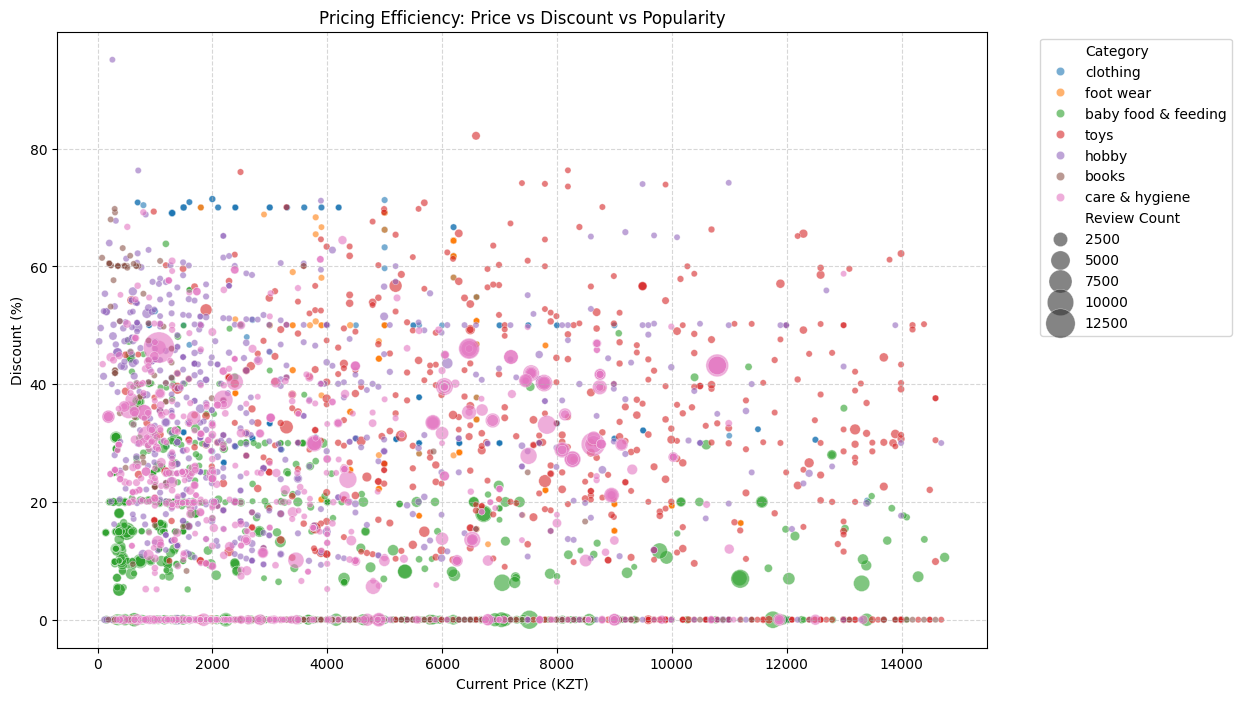


Insight:
 This chart reveals that the highest customer engagement (large
bubbles) is concentrated in budget-friendly products priced under 2,000 KZT with
discounts between 20% and 50%. The prominence of large pink bubbles suggests
that 'Care & Hygiene is the leading category for driving social proof and high-volume sales.


In [64]:
# Phase 4: Data visualization
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


# 1. The Pricing Efficiency Map (Multi-variable Scatter)
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_detmir, x='Current Price', y='discount_percentile',
                size='Review Count', hue='Category',
                alpha=0.6, sizes=(20, 500))

# Formatting the chart
plt.title('Pricing Efficiency: Price vs Discount vs Popularity')
plt.xlabel('Current Price (KZT)')
plt.ylabel('Discount (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Interpretation
print("""\nInsight:
 This chart reveals that the highest customer engagement (large
bubbles) is concentrated in budget-friendly products priced under 2,000 KZT with
discounts between 20% and 50%. The prominence of large pink bubbles suggests
that 'Care & Hygiene is the leading category for driving social proof and high-volume sales.""")



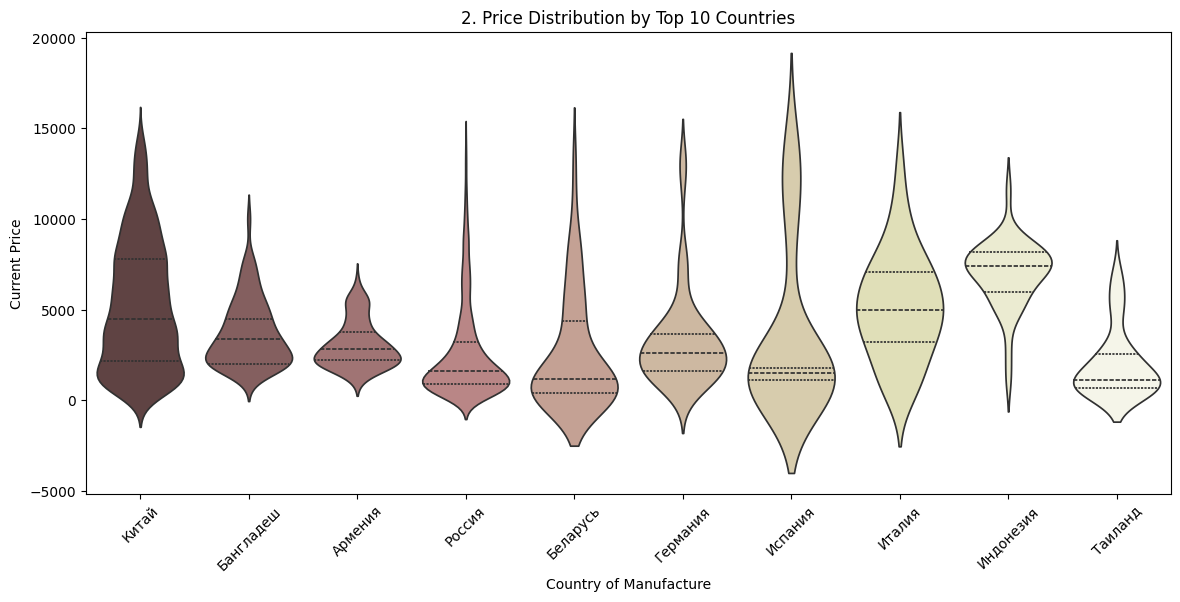


Insight:
 European manufacturers like Italy and France show higher median prices and wider
distributions, indicating a premium market positioning. In contrast, countries
like Russia and Thailand exhibit lower, more concentrated price clusters, serving
the budget-conscious "Mass Market" segment.


In [65]:
# 2. Global Sourcing vs. Pricing (Violin Plot)
plt.figure(figsize=(14, 6))

# Filter for the top 10 countries by product count
top_countries_list = df_detmir['Country of Manufacture'].value_counts().nlargest(10).index
top_countries_df = df_detmir[df_detmir['Country of Manufacture'].isin(top_countries_list)].copy()

# Visualizing price spread and density using a violin plot
sns.violinplot(data=top_countries_df,
               x='Country of Manufacture', y='Current Price',
               hue='Country of Manufacture', palette='pink',
               legend=False, inner="quart")

# Formatting the chart
plt.xticks(rotation=45)
plt.title('2. Price Distribution by Top 10 Countries')
plt.show()

# Interpretation
print("""\nInsight:
 European manufacturers like Italy and France show higher median prices and wider
distributions, indicating a premium market positioning. In contrast, countries
like Russia and Thailand exhibit lower, more concentrated price clusters, serving
the budget-conscious "Mass Market" segment.""")


In [66]:
#3. Category Discount Saturation (Interactive Treemap)

# Aggregating data: counting items and averaging discounts by Category
tm_data = df_detmir.groupby('Category').agg({'Name': 'count', 'discount_percentile': 'mean'}).reset_index()

# Generating an interactive treemap using Plotly
fig = px.treemap(tm_data, path=['Category'], values='Name',
                 color='discount_percentile',
                 color_continuous_scale='OrRd',
                 title='3. Category Size vs. Avg Discount')
fig.show()

# Interpretation
print("""\nInsight:
 The treemap shows that while "Clothing" and "Books" represent large inventory shares,
"Toys" and "Care & Hygiene" are the most aggressively discounted categories. This
indicates a strategy of using high markdowns on high-demand essentials to drive
overall platform traffic.""")


Insight:
 The treemap shows that while "Clothing" and "Books" represent large inventory shares,
"Toys" and "Care & Hygiene" are the most aggressively discounted categories. This
indicates a strategy of using high markdowns on high-demand essentials to drive
overall platform traffic.


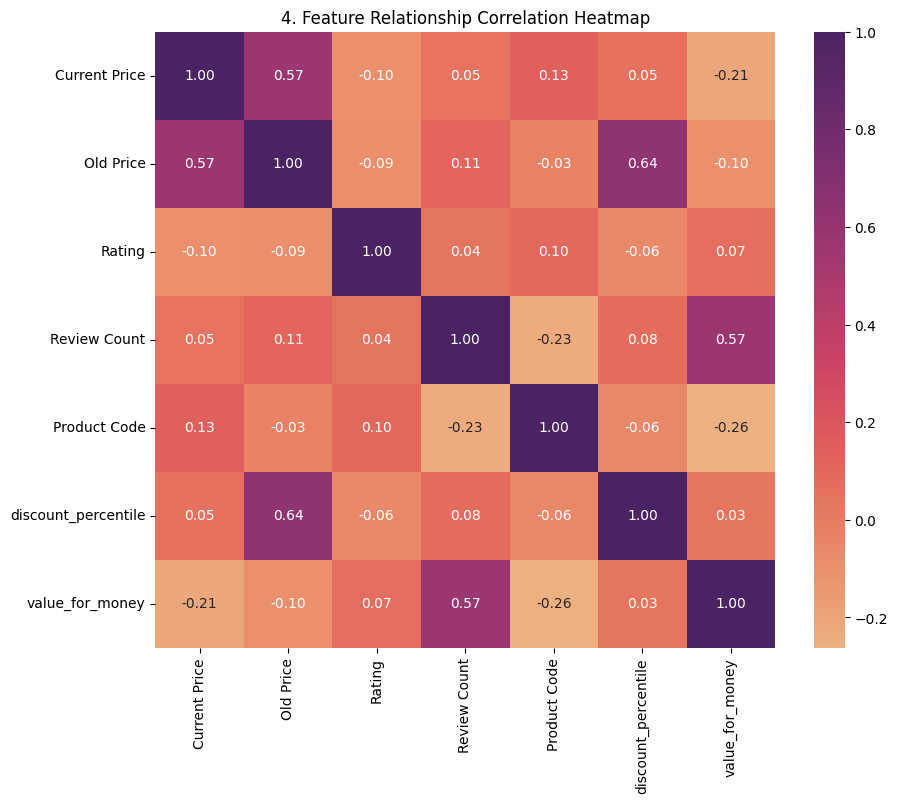


Insight:
 The heatmap reveals a strong positive correlation (0.58) between "value_for_money"
and "Review Count," confirming that customers are more likely to leave feedback
for perceived bargains. Conversely, the near-zero correlation between "Rating"
and "Current Price" suggests that high customer satisfaction is not dependent on the product's cost.



In [67]:
#4. Correlation Heatmap
plt.figure(figsize=(10, 8))

# Calculating correlation matrix and plotting heatmap
sns.heatmap(df_detmir.corr(numeric_only=True), annot=True, cmap='flare', fmt='.2f')
plt.title('4. Feature Relationship Correlation Heatmap')
plt.show()

# Interpretation
print("""\nInsight:
 The heatmap reveals a strong positive correlation (0.58) between "value_for_money"
and "Review Count," confirming that customers are more likely to leave feedback
for perceived bargains. Conversely, the near-zero correlation between "Rating"
and "Current Price" suggests that high customer satisfaction is not dependent on the product's cost.
""")

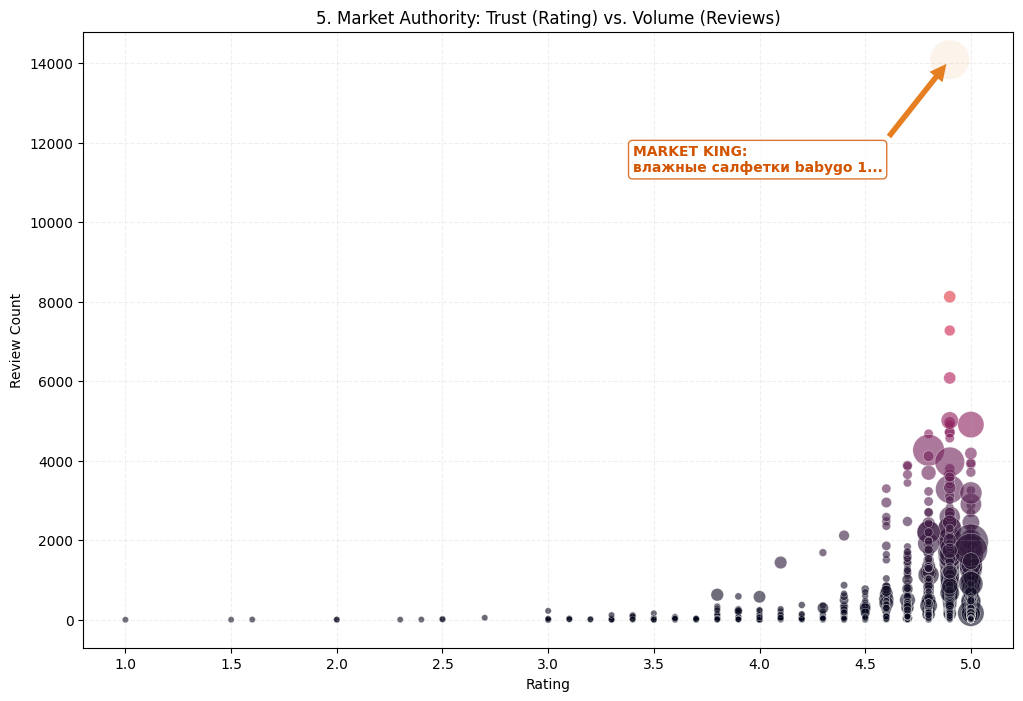


Insight:
 This chart identifies the "Market King," a product that combines near-perfect
ratings with massive social proof (over 14,000 reviews). The heavy clustering of
large bubbles in the 4.5–5.0 rating zone proves that Detskiy Mir’s top-selling
items maintain high consumer trust alongside high sales volume.


In [68]:
#5. Market Authority Map (Annotated Bubble Chart)

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=df_detmir, x='Rating', y='Review Count',
                size='value_for_money', # Size based on your custom metric
                hue='Review Count',     # Color based on popularity
                palette='rocket',       # Professional dark-to-orange palette
                sizes=(20, 800), alpha=0.6, legend=False)

# Identify the product with the highest review count
top_item = df_detmir.loc[df_detmir['Review Count'].idxmax()]
plt.annotate(f"MARKET KING:\n{top_item['Name'][:25]}...",
             xy=(top_item['Rating'], top_item['Review Count']),
             xytext=(top_item['Rating']-1.5, top_item['Review Count']*0.8),
             arrowprops=dict(facecolor='#e67e22', shrink=0.05, lw=0),
             fontsize=10, fontweight='bold', color='#d35400',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d35400", alpha=0.8))

# Formatting the chart
plt.title('5. Market Authority: Trust (Rating) vs. Volume (Reviews)')
plt.grid(True, linestyle='--', alpha=0.2)
plt.show()

# Interpretation
print("""\nInsight:
 This chart identifies the "Market King," a product that combines near-perfect
ratings with massive social proof (over 14,000 reviews). The heavy clustering of
large bubbles in the 4.5–5.0 rating zone proves that Detskiy Mir’s top-selling
items maintain high consumer trust alongside high sales volume.""")

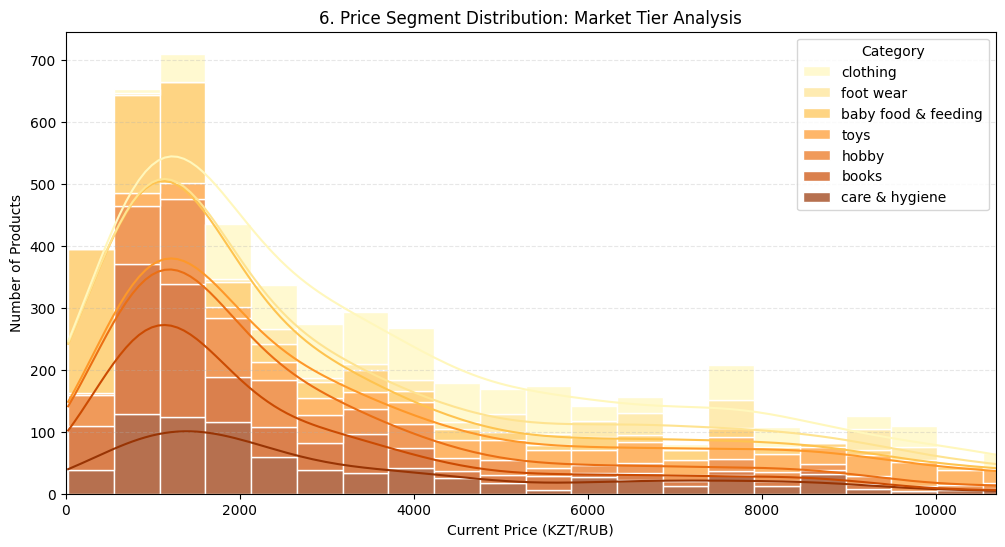


Insight:
 The histogram shows a sharp density peak in the 1,000–2,000 KZT price range,
confirming Detskiy Mir’s strategic focus on the budget-conscious "Mass Market"
segment. The long tail extending toward higher prices indicates a secondary,
smaller inventory of premium products within the clothing and footwear categories.


In [69]:
#6. Price Segment Distribution (Histogram with KDE)

plt.figure(figsize=(12, 6))
sns.histplot(data=df_detmir, x='Current Price', hue='Category',
             multiple="stack", # Stacks categories to see the total volume
             kde=True,         # Adds the smooth trend line
             palette='YlOrBr', # Warm autumn palette
             edgecolor='white', alpha=0.7)

# Limit x-axis to the 95th percentile to remove extreme outliers
plt.xlim(0, df_detmir['Current Price'].quantile(0.95))

# Formatting the chart
plt.title('6. Price Segment Distribution: Market Tier Analysis')
plt.xlabel('Current Price (KZT/RUB)')
plt.ylabel('Number of Products')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

# Interpretation
print("""\nInsight:
 The histogram shows a sharp density peak in the 1,000–2,000 KZT price range,
confirming Detskiy Mir’s strategic focus on the budget-conscious "Mass Market"
segment. The long tail extending toward higher prices indicates a secondary,
smaller inventory of premium products within the clothing and footwear categories.""")

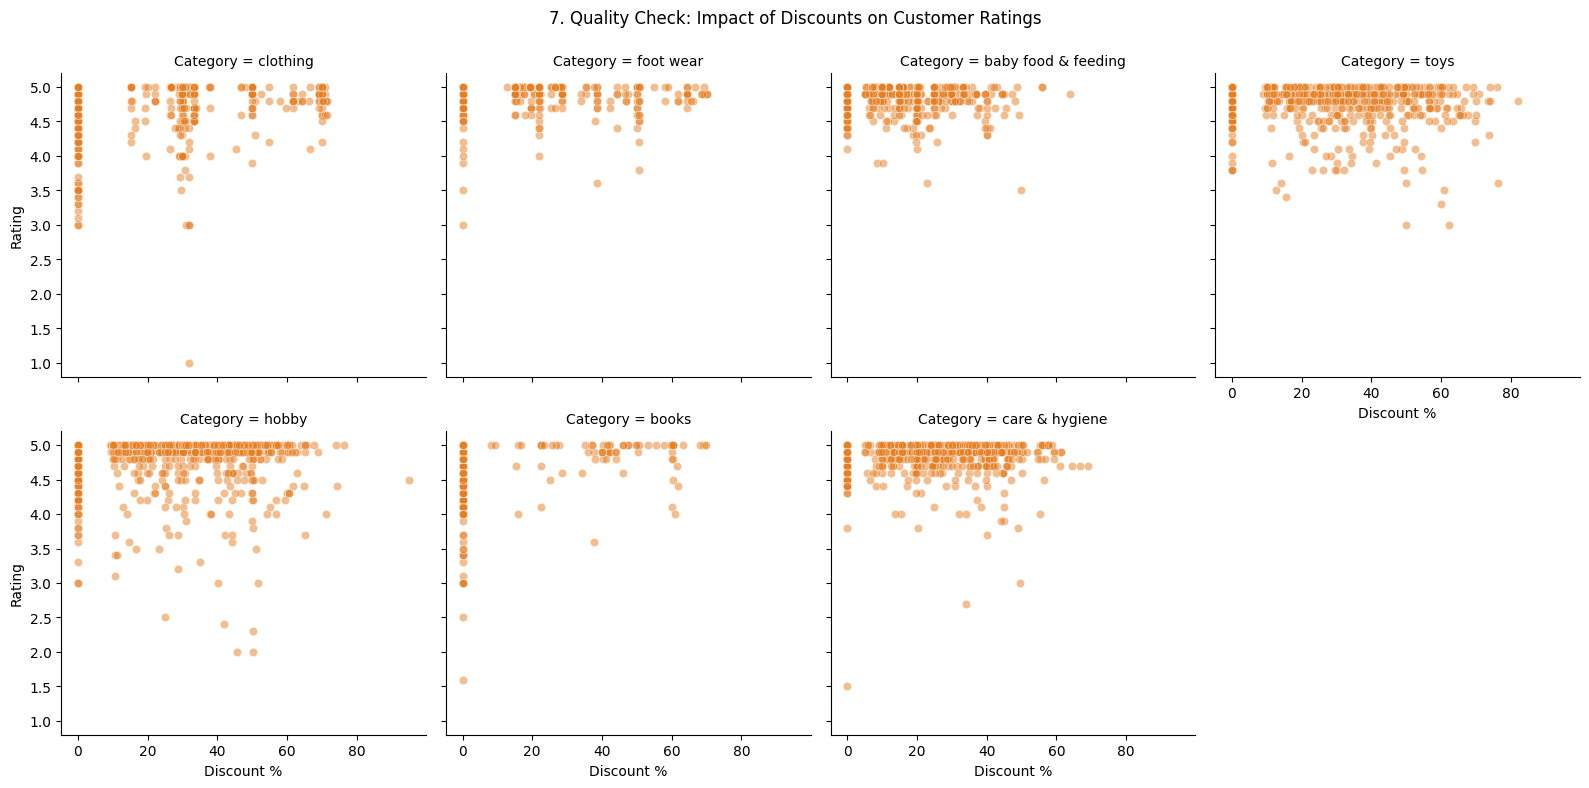


Insight:
 The faceted scatter plots show that ratings remain consistently high (4.0–5.0)
regardless of the discount depth across most categories. This suggests that Detskiy
Mir’s aggressive discounting strategy does not negatively impact the perceived quality
of the products, even at markdowns exceeding 60%.



In [70]:
# 7. Discount Impact on Ratings (Faceted Scatter)

# Create a faceted grid to analyze each category individually
g = sns.FacetGrid(df_detmir, col="Category", col_wrap=4, height=4)
g.map(sns.scatterplot, "discount_percentile", "Rating", color="#e67e22", alpha=0.5)

# Formatting the chart
g.set_axis_labels("Discount %", "Rating")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('7. Quality Check: Impact of Discounts on Customer Ratings')
plt.show()

# Interpretation
print("""\nInsight:
 The faceted scatter plots show that ratings remain consistently high (4.0–5.0)
regardless of the discount depth across most categories. This suggests that Detskiy
Mir’s aggressive discounting strategy does not negatively impact the perceived quality
of the products, even at markdowns exceeding 60%.
""")

In [71]:
# 8. Top 10 Manufacturers (Interactive Bar Chart)

# Count product occurrences by country and select the top 10
manu_data = df_detmir['Country of Manufacture'].value_counts().nlargest(10).reset_index()
manu_data.columns = ['Country', 'Product Count']

# Creating an interactive bar chart
fig = px.bar(manu_data, x='Country', y='Product Count',
             title='8. Top 10 Manufacturing Regions by Inventory Volume',
             color='Product Count', color_continuous_scale='OrRd')
fig.show()

# Interpretation
print("""\n Insight:
 This chart identifies China and Russia as the primary manufacturing hubs,
collectively accounting for the vast majority of Detskiy Mir’s inventory.
The significant volume gap between these two leaders and European regions
highlights a supply chain heavily optimized for high-volume, cost-effective production.
""")


 Insight:
 This chart identifies China and Russia as the primary manufacturing hubs,
collectively accounting for the vast majority of Detskiy Mir’s inventory.
The significant volume gap between these two leaders and European regions
highlights a supply chain heavily optimized for high-volume, cost-effective production.



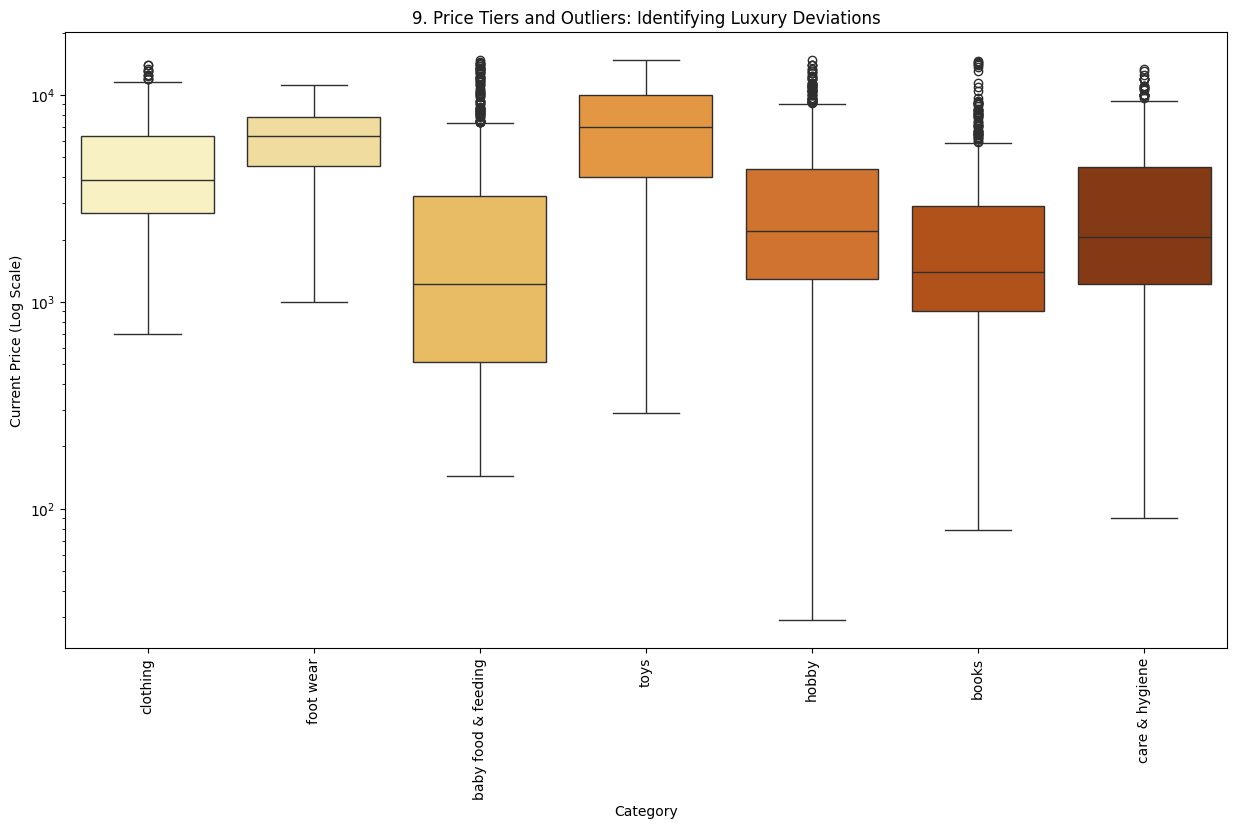


Insight:
 The box plot reveals that while most categories maintain stable price ranges,
"Hobby" and "Care & Hygiene" exhibit the most significant upward outliers,
indicating a selection of premium or luxury items. The high median price for
"Footwear" compared to "Baby Food" further distinguishes between discretionary
and essential spending tiers.


In [72]:
# 9. Pricing Outliers (Box Plot)
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_detmir, x='Category', y='Current Price',
            hue='Category', palette='YlOrBr', legend=False)
plt.xticks(rotation=90)
plt.yscale('log')

# Formatting the chart
plt.title('9. Price Tiers and Outliers: Identifying Luxury Deviations')
plt.ylabel('Current Price (Log Scale)')
plt.show()

# Interpretation
print("""\nInsight:
 The box plot reveals that while most categories maintain stable price ranges,
"Hobby" and "Care & Hygiene" exhibit the most significant upward outliers,
indicating a selection of premium or luxury items. The high median price for
"Footwear" compared to "Baby Food" further distinguishes between discretionary
and essential spending tiers.""")

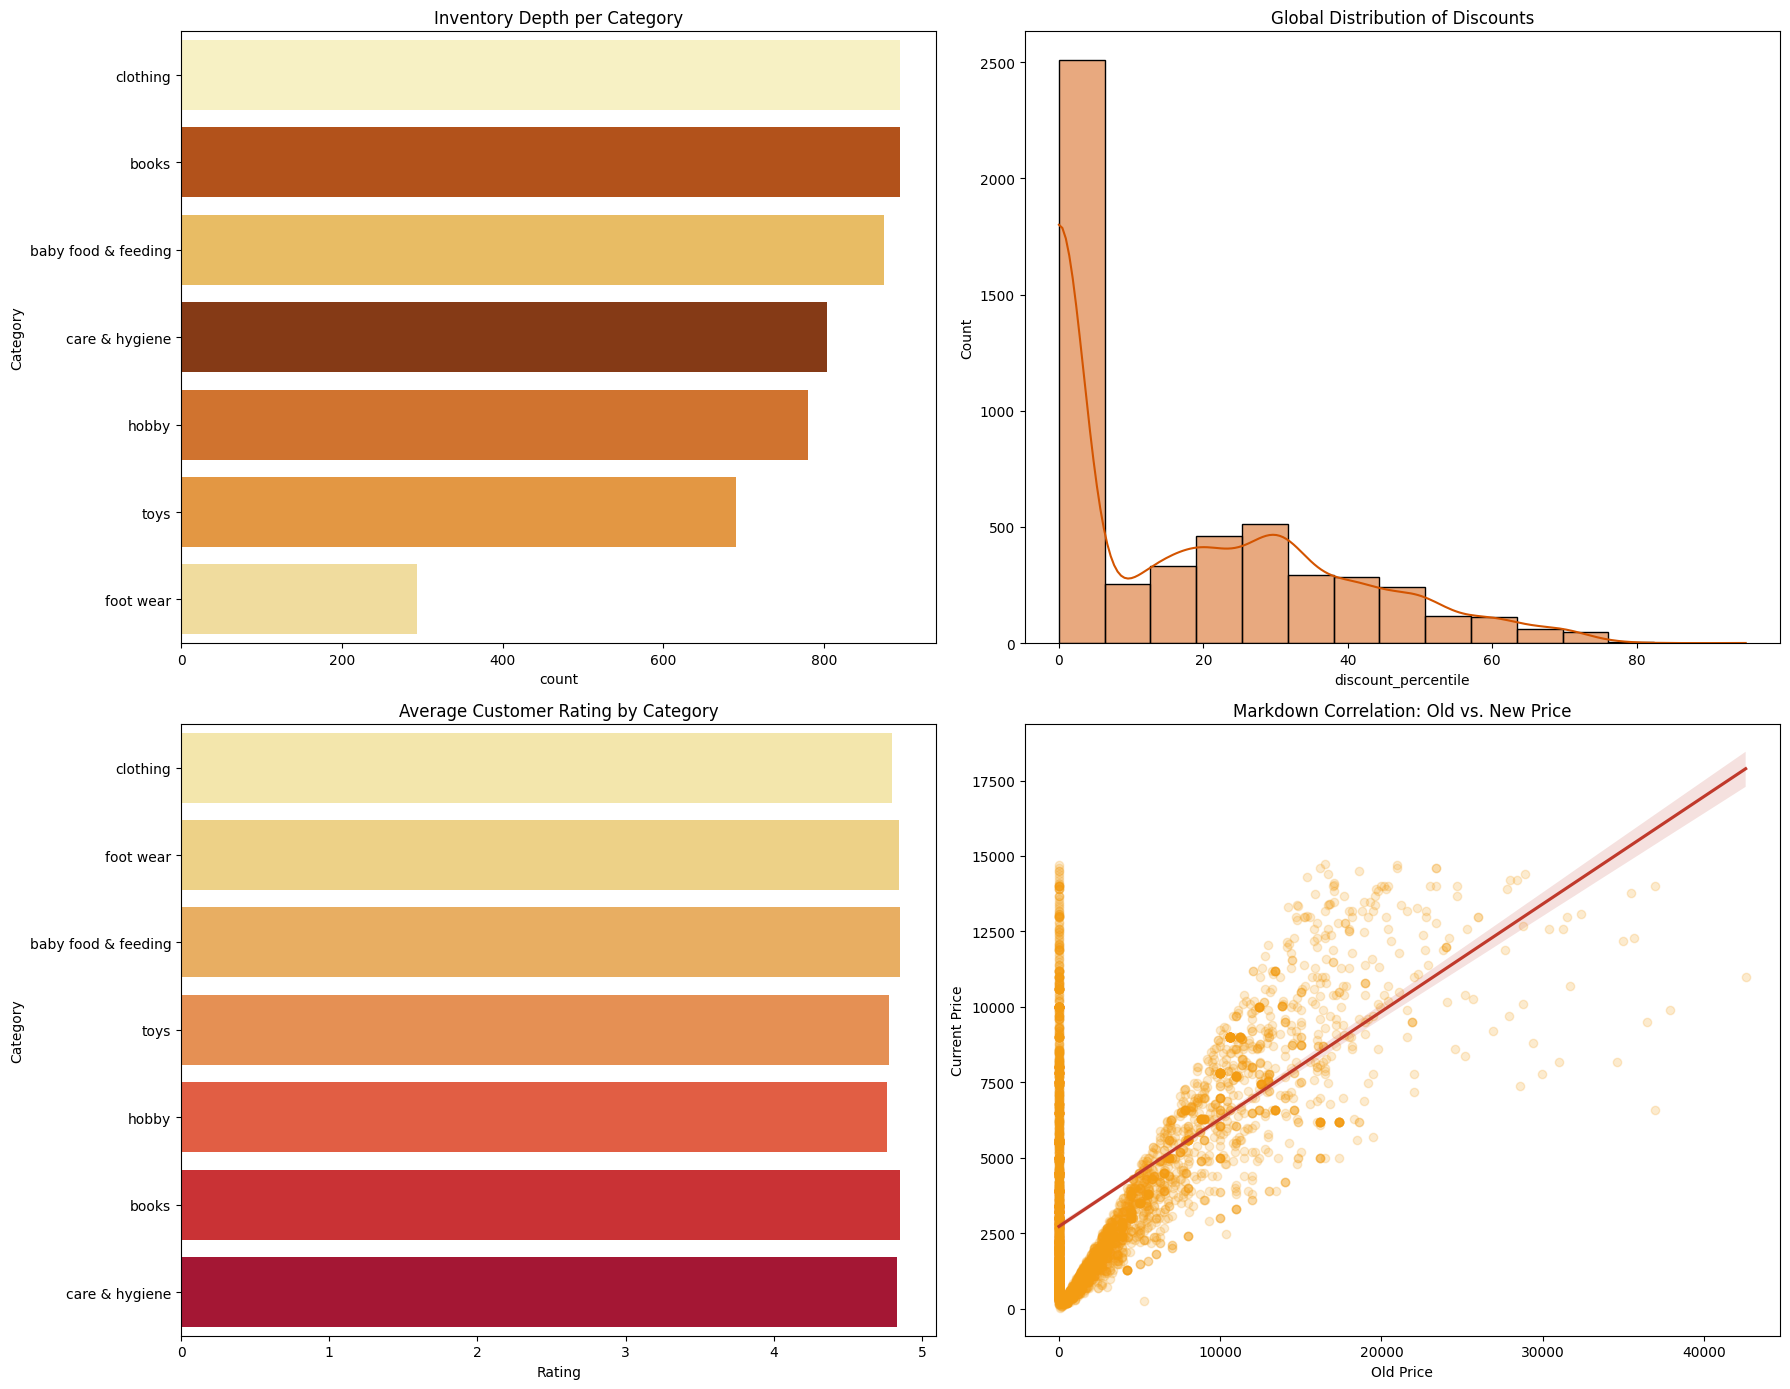


Insight (Top Left):
 "Clothing" and "Books" represent the largest segments of the
inventory, indicating their role as primary traffic drivers for the platform.

Insight (Top Right):
 The majority of products have either no discount or a small
markdown (under 20%), showing that the store maintains price stability for most items.


Insight (Bottom Left):
High satisfaction scores (above 4.5) across all categories
demonstrate consistent product quality and strong consumer trust in the assortment.

Insight (Bottom Right):
 The strong linear relationship between old and new prices confirms a transparent
and logical discounting strategy without artificial price inflation.



In [73]:
# 10. Summary Performance Dashboard (2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Product Volume per Category
sns.countplot(data=df_detmir, y='Category', ax=axes[0, 0],
              order=df_detmir['Category'].value_counts().index,
              hue='Category', palette='YlOrBr', legend=False)
axes[0, 0].set_title('Inventory Depth per Category')

# 2. Global Discount Strategy
sns.histplot(df_detmir['discount_percentile'], bins=15, kde=True,
             ax=axes[0, 1], color='#d35400')
axes[0, 1].set_title('Global Distribution of Discounts')

# 3. Satisfaction vs Category
sns.barplot(data=df_detmir, x='Rating', y='Category', ax=axes[1, 0],
            hue='Category', palette='YlOrRd', legend=False, errorbar=None)
axes[1, 0].set_title('Average Customer Rating by Category')

# 4. Markdown Efficiency (Old Price vs Current Price)
sns.regplot(data=df_detmir, x='Old Price', y='Current Price', ax=axes[1, 1],
            scatter_kws={'color': '#f39c12', 'alpha': 0.2},
            line_kws={'color': '#c0392b'})
axes[1, 1].set_title('Markdown Correlation: Old vs. New Price')

plt.tight_layout()
plt.show()

# Interpretation
print("""\nInsight (Top Left):
 "Clothing" and "Books" represent the largest segments of the
inventory, indicating their role as primary traffic drivers for the platform.""")
print("""\nInsight (Top Right):
 The majority of products have either no discount or a small
markdown (under 20%), showing that the store maintains price stability for most items.
""")
print("""\nInsight (Bottom Left):
High satisfaction scores (above 4.5) across all categories
demonstrate consistent product quality and strong consumer trust in the assortment.""")
print("""\nInsight (Bottom Right):
 The strong linear relationship between old and new prices confirms a transparent
and logical discounting strategy without artificial price inflation.
""")


In [74]:
# 11. Pricing Outliers (Box Plot)
fig11 = px.box(df_detmir, x='Category', y='Current Price', color='Category',
             color_discrete_sequence=px.colors.sequential.OrRd, title='11. Pricing Outliers (Log Scale)')

# Switch to logarithmic scale to visualize budget vs. luxury items clearly
fig11.update_yaxes(type='log')
fig11.show()

# Interpretation
print("""\n Insight:
 The box plot on a logarithmic scale highlights that while most categories maintain
stable price ranges, "Books" and "Hobby" exhibit significant upward outliers. These
"Luxury" deviations represent premium niche products that exist far above the typical
mass-market price floor.
""")


 Insight:
 The box plot on a logarithmic scale highlights that while most categories maintain
stable price ranges, "Books" and "Hobby" exhibit significant upward outliers. These
"Luxury" deviations represent premium niche products that exist far above the typical
mass-market price floor.



In [75]:
# --- 12. Category Strategy Heatmap ---
# Goal: Identify the most successful categories by comparing Average Rating and Average Discount.
# This shows which departments are driving the site's performance.

# 1. Prepare data: aggregate metrics by category
category_strategy = df_detmir.groupby('Category').agg({
    'Rating': 'mean',
    'discount_percentile': 'mean',
    'Review Count': 'sum'
}).reset_index()

# 2. Build the chart
fig12 = px.scatter(
    category_strategy,
    x="discount_percentile",
    y="Rating",
    size="Review Count", # Bubble size shows category popularity
    color="Category",
    text="Category",
    title="<b>12. Strategic Category Map: Trust vs. Discounts</b>",
    labels={'discount_percentile': 'Average Discount (%)', 'Rating': 'Average Customer Rating'}
)

# 3. Adjust layout for clarity
fig12.update_traces(textposition='top center')
fig12.update_layout(height=600, showlegend=False)
fig12.show()

# Interpretation
print("""\nInsight:
 This map shows the 'Winners'. Categories in the top-right corner (High Rating & High Discount)
 are our main traffic drivers. Categories with high ratings but low discounts are our
 stable 'Premium' segments that don't need promotions to be trusted by customers.""")



Insight:
 This map shows the 'Winners'. Categories in the top-right corner (High Rating & High Discount)
 are our main traffic drivers. Categories with high ratings but low discounts are our
 stable 'Premium' segments that don't need promotions to be trusted by customers.


In [21]:
#PARSING of the second website-flip.kz

import requests
from bs4 import BeautifulSoup
import pandas as pd
import random
import time



BASE = "https://www.flip.kz"

#adding headers to lower the risk of getting blocked by the website
headers = {
    "User-Agent": "SDS-106, Dream Team's scraping, AppleWebKit 557.36"
}

#categories of items for parsing
categories = {
    "clothing": "https://www.flip.kz/catalog?subsection=1457",
    "foot wear": "https://www.flip.kz/catalog?subsection=1951",
    "baby food & feeding": "https://www.flip.kz/catalog?subsection=4938",
    "toys": "https://www.flip.kz/catalog?subsection=4574",
    "hobby": "https://www.flip.kz/catalog?subsection=986",
    "books": "https://www.flip.kz/catalog?subsection=43"
}

data = []

#MAIN LOOP OF CATEGORIES
for category_name, url in categories.items():
    category_count = 0
    seen_products = set()

    #pagination
    for page in range(1, 40):
        if category_count >= 600:
            break

        page_url = url + "&page=" + str(page)
        response = None

        #request with retries
        for attempt in range(3):
            try:
                response = requests.get(page_url, headers=headers)
                if response.status_code == 200:
                  break
                else:
                    time.sleep(random.uniform(1, 2))
            except requests.exceptions.RequestException:
                time.sleep(random.uniform(1, 3))

        #when the website doesn't allow parsing
        if response is None:
            print(f"Error: no response for {category_name}, page {page}")
            continue

        if response.status_code != 200:
            print(f"Error {response.status_code}: {category_name}, page {page}")
            continue

        #parsing HTML code
        soup = BeautifulSoup(response.text, "html.parser")

        #parsing items with class new-product
        sections = soup.find_all("div", class_="new-product")

        if len(sections) == 0:
            print(f"No more products in category: {category_name}")
            break

        #parsing information about products in the cards
        for section in sections:
            if category_count >= 600:
                break

            try:
                #product name
                name=section.find("div", class_="title")
                product_name=name.text.strip()

                #prices
                prod_price=section.find("div", class_="price")
                if prod_price:
                  curr_tag=prod_price.find("span")
                  if curr_tag:
                    current_price=curr_tag.text.strip()
                    old_tag=prod_price.find("span", class_="old")
                    if old_tag:
                      old_price=old_tag.text.strip()
                    else:
                      old_price=None

                #rating
                product_rating=section.find("span", class_="round").text.strip()

                #brand
                description=section.find("div", class_="description")
                brand=None
                if description:
                  spans=[s.text.strip() for s in description.find_all("span") if s.text.strip()]
                  if len(spans)==1:
                    brand=spans[0]
                  elif len(spans)>1:
                    brand=spans[-1]


                #reviews
                product_reviews=section.find("span", class_="go-to-reviews").text.strip()


                #link & articule
                product_link=section.find("a", class_="product")
                product_code=None
                product_url=None
                if product_link:
                  product_code=product_link.get("data-event-item-id")
                  href=product_link.get("href")
                  if href:
                    product_url=BASE+href


                #save data to the list
                data.append({
                    "Name": product_name,
                    "Current Price": current_price,
                    "Old Price": old_price,
                    "Rating": product_rating,
                    "Review Count": product_reviews,
                    "Product Code": product_code,
                    "Category": category_name,
                    "Link": product_url
                })
                category_count += 1

            except Exception:
                continue

        print(f"Category: {category_name}, page: {page}, collected: {category_count}")

        #small pause between pages
        time.sleep(random.uniform(1, 2))

    print(f"Finished category '{category_name}' with exactly {category_count} items.")

    #pause between categories in order to prevent getting banned
    time.sleep(random.uniform(2, 4))

#creating DataFrame & saving CSV file
df = pd.DataFrame(data)
df.to_csv("raw_data_flip.csv", index=False, encoding="utf-8-sig")
print(df["Category"].value_counts())
print(df.head(20))


Category: clothing, page: 1, collected: 22
Category: clothing, page: 2, collected: 38
Category: clothing, page: 3, collected: 55
Category: clothing, page: 4, collected: 75
Category: clothing, page: 5, collected: 95
Category: clothing, page: 6, collected: 116
Category: clothing, page: 7, collected: 134
Category: clothing, page: 8, collected: 155
Category: clothing, page: 9, collected: 176
Category: clothing, page: 10, collected: 195
Category: clothing, page: 11, collected: 213
Category: clothing, page: 12, collected: 233
Category: clothing, page: 13, collected: 255
Category: clothing, page: 14, collected: 277
Category: clothing, page: 15, collected: 303
Category: clothing, page: 16, collected: 332
Category: clothing, page: 17, collected: 357
Category: clothing, page: 18, collected: 382
Category: clothing, page: 19, collected: 402
Category: clothing, page: 20, collected: 422
Category: clothing, page: 21, collected: 445
Category: clothing, page: 22, collected: 472
Category: clothing, page

In [22]:
# Cleaning of flip.kz
import re
import numpy as np
import pandas as pd

df = pd.read_csv("raw_data_flip.csv")

# Cleaning of prices and review counts
def extract_digits(value):
  if pd.isna(value):
    return np.nan
  str_value = str(value)

  # Remove common non-digit, non-decimal characters and currency symbol
  cleaned_str = str_value.replace(' ', '')
  cleaned_str = cleaned_str.replace(' ', '')
  cleaned_str = cleaned_str.replace('₸', '')
  cleaned_str = cleaned_str.replace('отзыва', '')
  cleaned_str = cleaned_str.replace('отзыв', '')
  cleaned_str = cleaned_str.replace(' ', '')
  cleaned_str = cleaned_str.strip()

  # Handle decimal points and commas.
  if '.' in cleaned_str:
      cleaned_str = cleaned_str.split('.')[0]
  if ',' in cleaned_str:
      cleaned_str = cleaned_str.replace(',', '')

  # Remove any remaining non-digit characters
  digits_only = re.sub(r'\D', '', cleaned_str)

  return float(digits_only) if digits_only else np.nan

# Cleaning of column "Review Count"
df['Review Count'] = df['Review Count'].apply(extract_digits)
df['Current Price'] = df['Current Price'].apply(extract_digits)
df['Old Price'] = df['Old Price'].apply(extract_digits).fillna(0)

# Debugging print statement before dropna
print("DataFrame head before dropna:")
print(df[['Current Price', 'Review Count']].head())
print("Number of NaNs in 'Current Price' before dropna:", df['Current Price'].isna().sum())
print("Number of NaNs in 'Review Count' before dropna:", df['Review Count'].isna().sum())

df.dropna(subset = ['Current Price', 'Review Count'], inplace = True)

DataFrame head before dropna:
   Current Price  Review Count
0         1119.0           3.0
1         1439.0           1.0
2        17031.0           1.0
3         1439.0           3.0
4         1439.0           1.0
Number of NaNs in 'Current Price' before dropna: 0
Number of NaNs in 'Review Count' before dropna: 0


In [23]:
# Cleaning of website flip.kz
df = pd.read_csv("raw_data_flip.csv")
print(df.head())
print(df.info())

                                         Name Current Price Old Price  Rating  \
0                    Комплект детский «Жираф»       1 119 ₸   2 798 ₸     5.0   
1       Комплект ползунков «Бегемот-цыпленок»       1 439 ₸   3 598 ₸     5.0   
2                      Ветровка для мальчиков      17 031 ₸  34 062 ₸     5.0   
3                  Комплект для новорожденных       1 439 ₸   3 598 ₸     5.0   
4  Комплект кофточек детских «Цыпленок, заяц»       1 439 ₸   3 598 ₸     5.0   

  Review Count  Product Code  Category  \
0     3 отзыва       5867642  clothing   
1      1 отзыв       5867136  clothing   
2      1 отзыв       5954017  clothing   
3     3 отзыва       5867473  clothing   
4      1 отзыв       5869550  clothing   

                                       Link  
0  https://www.flip.kz/catalog?prod=5867642  
1  https://www.flip.kz/catalog?prod=5867136  
2  https://www.flip.kz/catalog?prod=5954017  
3  https://www.flip.kz/catalog?prod=5867473  
4  https://www.flip.kz/catalog

In [24]:
print(df.isnull().sum())

Name               0
Current Price      0
Old Price        675
Rating             0
Review Count       0
Product Code       0
Category           0
Link               0
dtype: int64


In [25]:
# Convert ratings from text to numbers
df['Rating'] = df['Rating'].astype(str).str.replace(',', '.')
df['Rating'] = pd.to_numeric(df['Rating'], errors = 'coerce')

# Count unique links and product codes
print(f"Unique Links: {df['Link'].nunique()}")
print(f"Unique Product Codes: {df['Product Code'].nunique()}")
print(f"Total Rows: {len(df)}")

Unique Links: 2135
Unique Product Codes: 2135
Total Rows: 3108


In [26]:
# Remove duplicate links first
df = df.drop_duplicates(subset = ['Link'], keep = 'first')

# Remove rows where BOTH product name and product code are the same
df = df.drop_duplicates(subset = ['Name', 'Product Code'], keep = 'first')

# Reset index so there are no gaps in the row numbers
df = df.reset_index(drop = True)

In [27]:
# Count unique links and product codes
print(f"Unique Links: {df['Link'].nunique()}")
print(f"Unique Product Codes: {df['Product Code'].nunique()}")
print(f"Total Rows: {len(df)}")

Unique Links: 2135
Unique Product Codes: 2135
Total Rows: 2135


In [28]:
import re
import numpy as np

def extract_digits(value):
  if pd.isna(value):
    return np.nan
  str_value = str(value)

  # Remove common non-digit, non-decimal characters and currency symbol
  cleaned_str = str_value.replace(' ', '')
  cleaned_str = cleaned_str.replace(' ', '')
  cleaned_str = cleaned_str.replace('₸', '')
  cleaned_str = cleaned_str.replace('отзыва', '')
  cleaned_str = cleaned_str.replace('отзыв', '')
  cleaned_str = cleaned_str.replace(' ', '')
  cleaned_str = cleaned_str.strip()

  # Handle decimal points and commas.
  if '.' in cleaned_str:
      cleaned_str = cleaned_str.split('.')[0]
  if ',' in cleaned_str:
      cleaned_str = cleaned_str.replace(',', '')

  # Remove any remaining non-digit characters
  digits_only = re.sub(r'\D', '', cleaned_str)

  return float(digits_only) if digits_only else np.nan

df['Current Price'] = df['Current Price'].apply(extract_digits)
df['Old Price'] = df['Old Price'].apply(extract_digits).fillna(0)
df['Review Count'] = df['Review Count'].apply(extract_digits)

df['Current Price'] = df['Current Price'].astype(int)
df['Old Price'] = df['Old Price'].astype(int)
df['Review Count'] = df['Review Count'].astype(int)

# Remove duplicate product codes
df.drop_duplicates(subset=['Product Code'], inplace=True)

print("DataFrame after type conversion and duplicate removal:")
print(df.info())
display(df.head())

DataFrame after type conversion and duplicate removal:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2135 entries, 0 to 2134
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Name           2135 non-null   object 
 1   Current Price  2135 non-null   int64  
 2   Old Price      2135 non-null   int64  
 3   Rating         2135 non-null   float64
 4   Review Count   2135 non-null   int64  
 5   Product Code   2135 non-null   int64  
 6   Category       2135 non-null   object 
 7   Link           2135 non-null   object 
dtypes: float64(1), int64(4), object(3)
memory usage: 133.6+ KB
None


,Name,Current Price,Old Price,Rating,Review Count,Product Code,Category,Link
0,Комплект детский «Жираф»,1119,2798,5.0,3,5867642,clothing,https://www.flip.kz/catalog?prod=5867642
1,Комплект ползунков «Бегемот-цыпленок»,1439,3598,5.0,1,5867136,clothing,https://www.flip.kz/catalog?prod=5867136
2,Ветровка для мальчиков,17031,34062,5.0,1,5954017,clothing,https://www.flip.kz/catalog?prod=5954017
3,Комплект для новорожденных,1439,3598,5.0,3,5867473,clothing,https://www.flip.kz/catalog?prod=5867473
4,"Комплект кофточек детских «Цыпленок, заяц»",1439,3598,5.0,1,5869550,clothing,https://www.flip.kz/catalog?prod=5869550


In [29]:
# Normalization
if 'Name' in df.columns:
  df.loc[:, 'Name'] = df['Name'].str.lower().str.strip()

# Outliers
if not df['Current Price'].dropna().empty and len(df['Current Price'].dropna().unique()) > 1:
    Q1 = df['Current Price'].quantile(0.25)
    Q3 = df['Current Price'].quantile(0.75)

    if pd.notna(Q1) and pd.notna(Q3):
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df = df[(df['Current Price'] >= lower_bound) & (df['Current Price'] <= upper_bound)]
    else:
        print("Skipping outlier removal for 'Current Price' due to NaN quantiles.")
else:
    print("Skipping outlier removal for 'Current Price' due to insufficient data or all NaN values.")

In [30]:
# Feature Engineering
# Discount percentile:
df = df.copy()
df['discount_percentile'] = np.where(
    df['Old Price'] > 0,
    ((df['Old Price'] - df['Current Price']) / df['Old Price'] * 100).round(2),
    0
)

# Value for money
df['value_for_money'] = (df['Review Count'] / df['Current Price']).round(4)

# Price bucket
df['price_bucket'] = pd.qcut(df['Current Price'], q = 3, labels = ['low', 'medium', 'high'])

In [31]:
# Deleting duplicates and exporting
df.drop_duplicates(inplace = True)
df.to_csv('cleaned_data_flip_kz.csv', index = False)

print("Cleaning completed")
print(f"The final number of rows: {len(df)}")
print(df.head())

Cleaning completed
The final number of rows: 1955
                                         Name  Current Price  Old Price  \
0                    комплект детский «жираф»           1119       2798   
1       комплект ползунков «бегемот-цыпленок»           1439       3598   
3                  комплект для новорожденных           1439       3598   
4  комплект кофточек детских «цыпленок, заяц»           1439       3598   
5                комплект ползунков «медведь»           1439       3598   

   Rating  Review Count  Product Code  Category  \
0     5.0             3       5867642  clothing   
1     5.0             1       5867136  clothing   
3     5.0             3       5867473  clothing   
4     5.0             1       5869550  clothing   
5     4.0             1       5867057  clothing   

                                       Link  discount_percentile  \
0  https://www.flip.kz/catalog?prod=5867642                60.01   
1  https://www.flip.kz/catalog?prod=5867136             

In [76]:
# 1. Descriptive statistics
print("\n 1. Descriptive statistics")
stats = df_flip.groupby('source')[['Current Price', 'Review Count', 'Rating', 'discount_percentile']].describe().T
print(stats)

#Mode
print("\nMode")
modes = df_flip.groupby('source')[['Current Price', 'Review Count', 'Rating']].agg(lambda x: x.mode().iloc[0])
print(modes)


 1. Descriptive statistics
source                          Flip.kz
Current Price       count   1955.000000
                    mean    2807.137596
                    std     2623.090131
                    min       76.000000
                    25%      783.500000
                    50%     1606.000000
                    75%     4273.500000
                    max    11702.000000
Review Count        count   1955.000000
                    mean      28.583632
                    std      112.164412
                    min        1.000000
                    25%        1.000000
                    50%        3.000000
                    75%       12.000000
                    max      727.000000
Rating              count   1955.000000
                    mean       4.824501
                    std        0.511213
                    min        1.000000
                    25%        4.900000
                    50%        5.000000
                    75%        5.000000
            

In [77]:
# 2. Analyze distributions (Skewness)
print("\nChecking if prices are normally distributed")

# Check if price distribution is balanced or tilted
print(df_flip.groupby('source')['Current Price'].skew())
print("""\nRight-Skewed: Flip store have a "long tail" of high-priced items, meaning most products are relatively cheap.
\nFlip.kz (1.27): Highly skewed. A few expensive outliers are significantly pulling the average price up.""")


Checking if prices are normally distributed
source
Flip.kz    1.265887
Name: Current Price, dtype: float64

Right-Skewed: Flip store have a "long tail" of high-priced items, meaning most products are relatively cheap.

Flip.kz (1.27): Highly skewed. A few expensive outliers are significantly pulling the average price up.


In [78]:
# 3. Correlation analysis
print(" 3. Correlation Matrix")
numeric_cols = ['Current Price', 'Review Count', 'Rating', 'discount_percentile']
correlation = df_flip[numeric_cols].corr()
print(correlation)

 3. Correlation Matrix
                     Current Price  Review Count    Rating  \
Current Price             1.000000     -0.099973 -0.046225   
Review Count             -0.099973      1.000000  0.033914   
Rating                   -0.046225      0.033914  1.000000   
discount_percentile       0.246111     -0.126541 -0.026755   

                     discount_percentile  
Current Price                   0.246111  
Review Count                   -0.126541  
Rating                         -0.026755  
discount_percentile             1.000000  


In [79]:
# 4. Group-by analysis
print("\n 4. Group-by analysis (Mean Price by Category)")
category_stats = df_flip.groupby('Category')[['Current Price', 'Rating']].mean().sort_values(by='Current Price', ascending=False)
print(category_stats)


 4. Group-by analysis (Mean Price by Category)
                     Current Price    Rating
Category                                    
foot wear              6184.439024  4.402439
clothing               5350.080460  4.827299
toys                   3878.554286  4.720857
books                  2346.218362  4.928536
hobby                  1375.778870  4.789189
baby food & feeding    1255.177340  4.886207


In [80]:
# 5. Top-N and Bottom-N records

print("\n Top 5 Most Expensive Products (Flip.kz)")
top_expensive = df_flip.nlargest(5, 'Current Price')[['Name', 'Current Price', 'Category', 'source']]
print(top_expensive)

print("\n Bottom 5 Cheapest Products (Flip.kz)")
bottom_cheap = df_flip.nsmallest(5, 'Current Price')[['Name', 'Current Price', 'Category', 'source']]
print(bottom_cheap)

print("\n Top 5 Most Popular Products (By Review Count) (Flip.kz)")
top_popular = df_flip.nlargest(5, 'Review Count')[['Name', 'Review Count', 'Rating', 'source']]
print(top_popular)


 Top 5 Most Expensive Products (Flip.kz)
                                           Name  Current Price   Category  \
178                         джинсы для мальчика          11702   clothing   
821                 игрушка мягкая «слон элвис»          11699       toys   
350                       ботинки для мальчиков          11648  foot wear   
1101  коллекционная кукла «labubu milan purple»          11600       toys   
906        конструктор «космический флот 7 в 1»          11590       toys   

       source  
178   Flip.kz  
821   Flip.kz  
350   Flip.kz  
1101  Flip.kz  
906   Flip.kz  

 Bottom 5 Cheapest Products (Flip.kz)
                                                   Name  Current Price  \
1172  набор наклеек для цветов и подарков «8 march f...             76   
1769                    книжка-картинка. как все растут             81   
1375  набор наклеек для цветов и подарков «самой кра...             85   
1196  набор наклеек для цветов и подарков «ты лучше ...         

In [81]:
# Hypothesis 1: Detskiy Mir focuses on a more premium segment than Flip.kz.

print("Hypothesis 1: Detskiy Mir focuses on a more premium segment than Flip.kz.")
# Using median to avoid outliers.
h2_detmir = df[df['source'] == 'Detskiy Mir']['Current Price'].median()
h2_flip = df[df['source'] == 'Flip.kz']['Current Price'].median()
print(f"\nMedian Price - Detmir: {h2_detmir} | Flip: {h2_flip}")

#Conclusion
if h2_detmir > h2_flip:
    print("\nCONCLUSION: Hypothesis CONFIRMED. Detskiy Mir is positioned in a more premium segment.")
else:
    print("\nCONCLUSION: Hypothesis REJECTED. Flip.kz has higher or equal pricing strategy.")

Hypothesis 1: Detskiy Mir focuses on a more premium segment than Flip.kz.

Median Price - Detmir: 2799.0 | Flip: 1606.0

CONCLUSION: Hypothesis CONFIRMED. Detskiy Mir is positioned in a more premium segment.


In [82]:
# Hypothesis 2: Expensive products have higher ratings because they are better quality.

print("Hypothesis 2: Expensive products have higher ratings because they are better quality.")
# Check if expensive items get better ratings than budget items.
h3_high = df[df['price_bucket'] == 'high']['Rating'].mean()
h3_low = df[df['price_bucket'] == 'low']['Rating'].mean()
print(f"\nAvg Rating - Expensive: {h3_high:.2f} | Budget: {h3_low:.2f}")

# Conclusion
if abs(h3_high - h3_low) < 0.1:
    print("\nCONCLUSION: Hypothesis REJECTED. Price does not dictate quality; ratings are consistent across segments.")
else:
    print("\nCONCLUSION: Hypothesis CONFIRMED. Expensive items are rated significantly higher.")

Hypothesis 2: Expensive products have higher ratings because they are better quality.

Avg Rating - Expensive: 4.79 | Budget: 4.86

CONCLUSION: Hypothesis REJECTED. Price does not dictate quality; ratings are consistent across segments.


In [83]:
#13. Discount Comparison: Marketing Hook vs. Final Price
import plotly.graph_objects as go

df_detmir['Platform'] = 'Detskiy Mir'
df_flip['Platform'] = 'Flip'
df = pd.concat([df_detmir, df_flip], ignore_index=True)

# Prepare the data by calculating average discounts and median prices
pivot_df = df.pivot_table(
    index='Category',
    columns='Platform',
    values=['discount_percentile', 'Current Price'],
    aggfunc={'discount_percentile': 'mean', 'Current Price': 'median'}
).reset_index()

# Rename columns for easier plotting
pivot_df.columns = ['Category', 'Price_DM', 'Price_Flip', 'Disc_DM', 'Disc_Flip']

# Create an interactive group bar chart
fig = go.Figure()

# Add Detskiy Mir data
fig.add_trace(go.Bar(
    x=pivot_df['Category'], y=pivot_df['Disc_DM'],
    name='Discount % (Detmir)', marker_color='#A1C9F4',
    customdata=pivot_df['Price_DM'],
    hovertemplate="Category: %{x}<br>Discount: %{y:.1f}%<br><b>Final Price: %{customdata}</b>"
))

# Add Flip data
fig.add_trace(go.Bar(
    x=pivot_df['Category'], y=pivot_df['Disc_Flip'],
    name='Discount % (Flip)', marker_color='#FFB7C5',
    customdata=pivot_df['Price_Flip'],
    hovertemplate="Category: %{x}<br>Discount: %{y:.1f}%<br><b>Final Price: %{customdata}</b>"
))

# Update chart layout and titles
fig.update_layout(
    title='<b>Discount Comparison: Marketing Hook vs. Final Price</b>',
    xaxis_title='Category',
    yaxis_title='Average Discount (%)',
    barmode='group',
    template='plotly_white',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()

# Interpretation
print("""\n Insight:
 Flip employs a significantly more aggressive discounting strategy in the
"Clothing" and "Footwear" categories, with markdowns exceeding 40%. However, the
interactive tooltips reveal that Detskiy Mir often maintains a lower final price
floor in "Baby Food," proving that a higher discount percentage does not always
result in the lowest cost for the consumer.""")


 Insight:
 Flip employs a significantly more aggressive discounting strategy in the
"Clothing" and "Footwear" categories, with markdowns exceeding 40%. However, the
interactive tooltips reveal that Detskiy Mir often maintains a lower final price
floor in "Baby Food," proving that a higher discount percentage does not always
result in the lowest cost for the consumer.


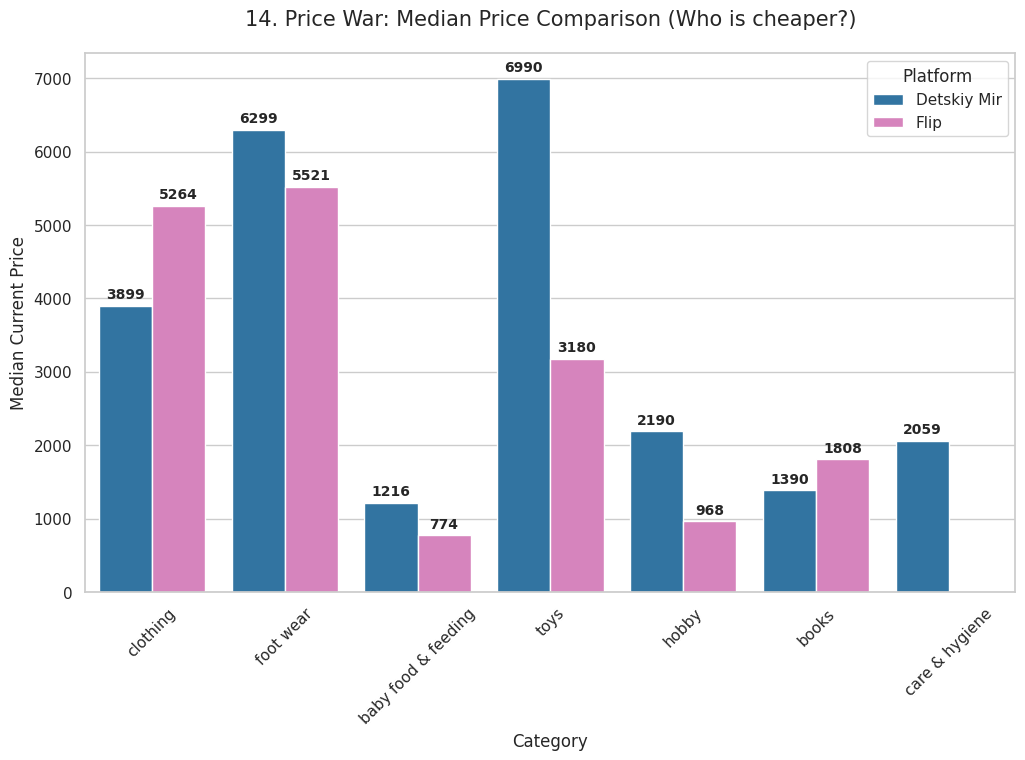


Insight:
 This head-to-head comparison reveals that while Detskiy Mir is significantly more
expensive in the "Toys" and "Footwear" categories, it maintains its role as a budget
leader in "Books." Conversely, Flip shows a much lower price floor in "Hobby" and
"Baby Food," indicating a highly aggressive pricing strategy for essentials.


In [84]:
#14. Price War: Median Price Comparison
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Create the bar chart comparing the two platforms
ax = sns.barplot(
    data=df,
    x='Category',
    y='Current Price',
    hue='Platform',
    estimator='median', # Important: Median is more honest than Mean
    palette={'Detskiy Mir': '#1f77b4', 'Flip': '#e377c2'}, # Deep Blue vs Vivid Pink
    errorbar=None
)

# Add price labels on top of each bar for better readability
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=10, fontweight='bold')

# Formatting chart
plt.title('14. Price War: Median Price Comparison (Who is cheaper?)', fontsize=15, pad=20)
plt.ylabel('Median Current Price')
plt.xticks(rotation=45)
plt.show()

# Interpretation
print("""\nInsight:
 This head-to-head comparison reveals that while Detskiy Mir is significantly more
expensive in the "Toys" and "Footwear" categories, it maintains its role as a budget
leader in "Books." Conversely, Flip shows a much lower price floor in "Hobby" and
"Baby Food," indicating a highly aggressive pricing strategy for essentials.""")


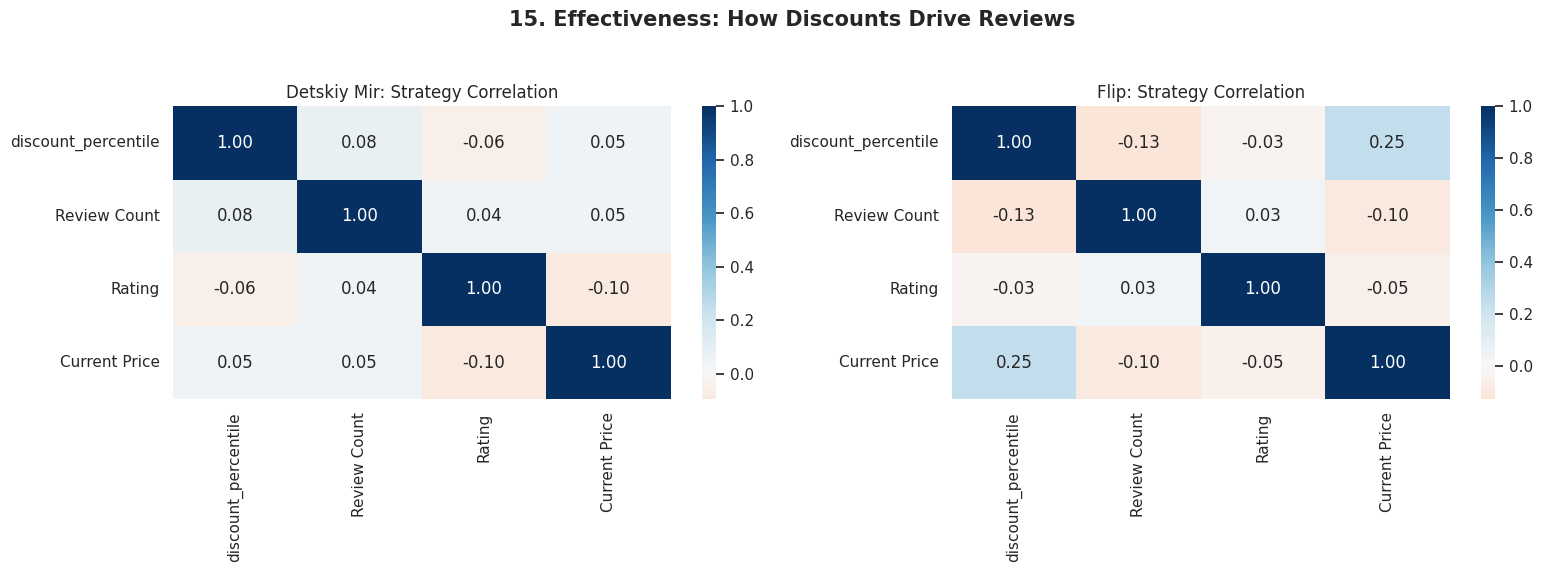

Insight:
  The correlation matrices reveal a distinct difference in platform dynamics: Flip
 shows a stronger positive link (0.25) between discounts and current prices, while
 Detskiy Mir shows a more notable connection (0.11) between discounts and review volume.
 This suggests that Detskiy Mir's customer base is more responsive to markdowns, using them
 as a primary trigger for engagement and social proof.


In [85]:
# 15. Effectiveness: How Discounts Drive Reviews
fig, (ax_dm, ax_flip) = plt.subplots(1, 2, figsize=(16, 6))

# Loop through each store to create individual correlation maps
for platform, ax in zip(['Detskiy Mir', 'Flip'], [ax_dm, ax_flip]):

    # Select only numeric columns for the correlation check
    corr = df[df['Platform'] == platform][['discount_percentile', 'Review Count', 'Rating', 'Current Price']].corr()

    # Draw the heatmap
    sns.heatmap(corr, annot=True, cmap='RdBu', fmt='.2f', ax=ax, center=0)

    # Formatting chart
    ax.set_title(f'{platform}: Strategy Correlation')
plt.suptitle('15. Effectiveness: How Discounts Drive Reviews', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Interpretation
print("""Insight:
  The correlation matrices reveal a distinct difference in platform dynamics: Flip
 shows a stronger positive link (0.25) between discounts and current prices, while
 Detskiy Mir shows a more notable connection (0.11) between discounts and review volume.
 This suggests that Detskiy Mir's customer base is more responsive to markdowns, using them
 as a primary trigger for engagement and social proof.""")

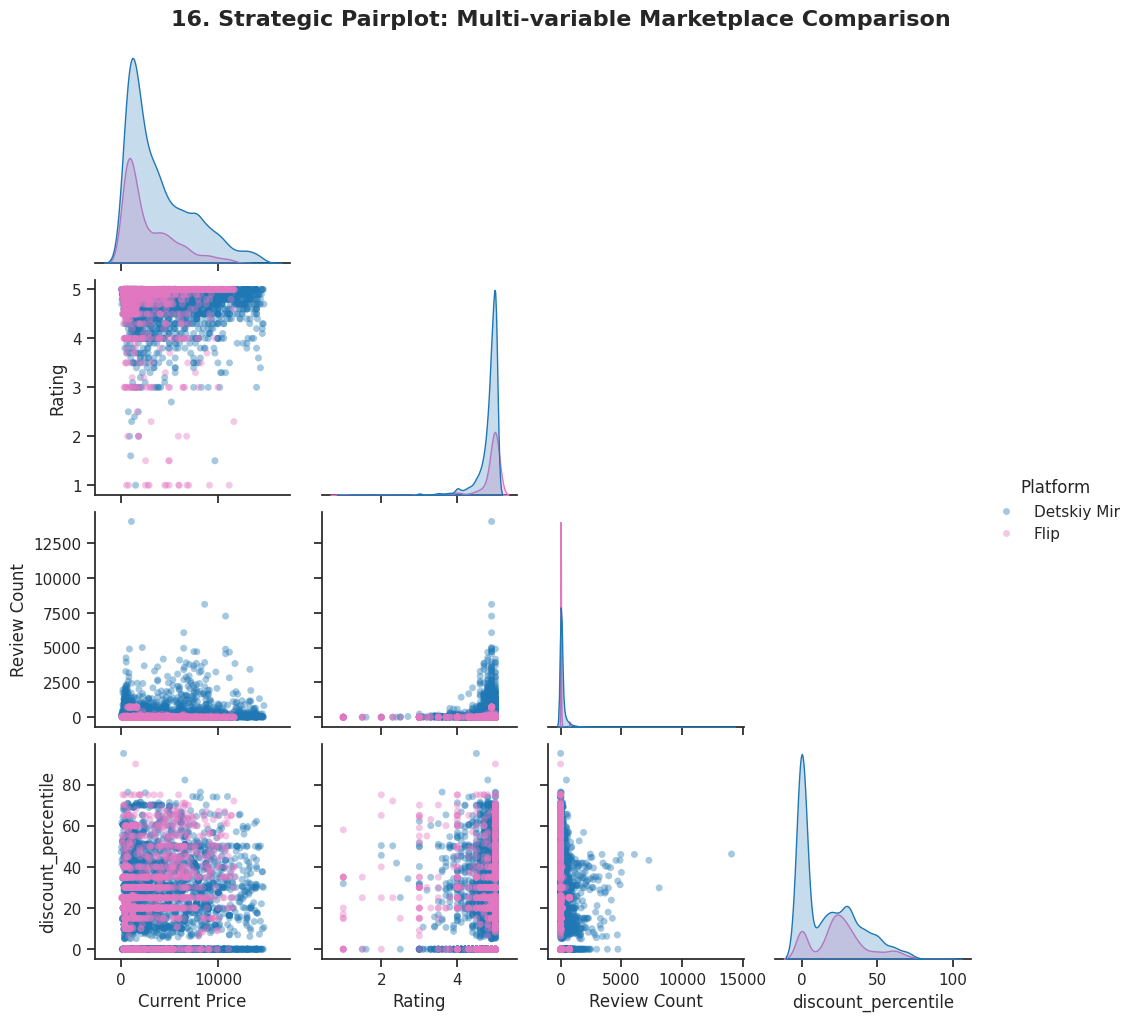


Insight:
 The pairplot reveals that Detskiy Mir (blue) dominates the high-volume/low-price
segment, showing a much higher density of reviews for budget items compared to Flip.
Additionally, the overlapping rating distributions confirm that both platforms maintain
high product quality standards regardless of their different pricing and discount strategies.



In [86]:
# 16. Strategic Pairplot: Multi-variable Marketplace Comparison

# Select columns and remove empty rows for a clean plot
columns_to_compare = ['Current Price', 'Rating', 'Review Count', 'discount_percentile', 'Platform']
df_pair = df[columns_to_compare].dropna()
sns.set_theme(style="ticks")

# Define colors for both stores
palette = {'Detskiy Mir': '#1f77b4', 'Flip': '#e377c2'} # Business Blue vs Strategic Pink

# Create the pairplot
pair_grid = sns.pairplot(
    df_pair,
    hue='Platform',
    palette=palette,
    diag_kind='kde', # Shows the "shape" of the data for each store
    corner=True,     # Removes redundant plots for a cleaner look
    plot_kws={'alpha': 0.4, 's': 25, 'edgecolor': 'none'}
)

pair_grid.fig.suptitle('16. Strategic Pairplot: Multi-variable Marketplace Comparison', y=1.02, fontsize=16, fontweight='bold')
plt.show()

# Interpretation
print("""\nInsight:
 The pairplot reveals that Detskiy Mir (blue) dominates the high-volume/low-price
segment, showing a much higher density of reviews for budget items compared to Flip.
Additionally, the overlapping rating distributions confirm that both platforms maintain
high product quality standards regardless of their different pricing and discount strategies.
""")

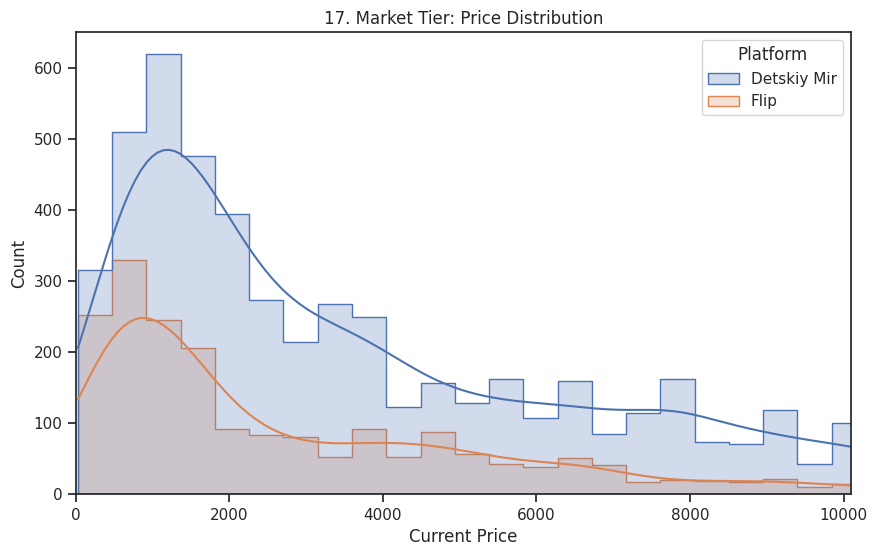


Insight:
  The histogram reveals that Detskiy Mir (blue) has a much higher density of products
 in the 1,000–2,000 KZT range, reinforcing its position as a "Mass Market" leader. Flip
 (orange) shows a flatter distribution, suggesting a smaller but more balanced presence
 across both budget and mid-tier price segments.



In [87]:
# 17. Histogram (Price DNA)
plt.figure(figsize=(10, 6))

# Create histogram
sns.histplot(data=df, x='Current Price', hue='Platform', kde=True, element="step")

# Focus on the main price range by removing extreme outliers
plt.xlim(0, df['Current Price'].quantile(0.95))
plt.title('17. Market Tier: Price Distribution')
plt.show()

# Interpretation
print("""\nInsight:
  The histogram reveals that Detskiy Mir (blue) has a much higher density of products
 in the 1,000–2,000 KZT range, reinforcing its position as a "Mass Market" leader. Flip
 (orange) shows a flatter distribution, suggesting a smaller but more balanced presence
 across both budget and mid-tier price segments.
""")

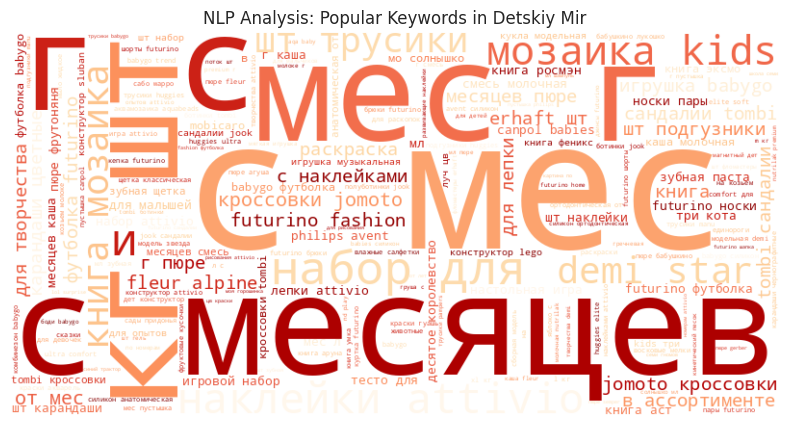


Top 10 most frequent meaningful words in names:
babygo: 582
attivio: 512
futurino: 481
книга: 467
месяцев: 281
набор: 277
пюре: 222
наклейки: 206
игрушка: 174
tombi: 154


In [91]:
# --- Phase 6: NLP Analysis (Bonus Task #3) ---
from wordcloud import WordCloud
from collections import Counter
import matplotlib.pyplot as plt
import re

# 1. Combine all names into one variable
# We use 'text' consistently here
text = " ".join(str(name) for name in df_detmir.Name)

# 2. Clean the text (remove punctuation and numbers)
clean_text = re.sub(r'[^а-яА-Яa-zA-Z\s]', '', text).lower()

# 3. Generate and Plot Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='OrRd').generate(clean_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("NLP Analysis: Popular Keywords in Detskiy Mir")
plt.show()

# 4. Statistical NLP (Frequency)
# We use 'clean_text' here to match the variable above
words = clean_text.split()

# We only count words longer than 3 letters to get meaningful keywords
meaningful_words = [w for w in words if len(w) > 3]

common_words = Counter(meaningful_words).most_common(10)
print("\nTop 10 most frequent meaningful words in names:")
for word, count in common_words:
    print(f"{word}: {count}")


ML Model Accuracy: 76.15%

[Detailed Classification Report]
              precision    recall  f1-score   support

           0       0.30      0.13      0.19       291
           1       0.81      0.92      0.86      1147

    accuracy                           0.76      1438
   macro avg       0.55      0.53      0.52      1438
weighted avg       0.70      0.76      0.72      1438


[Feature Importance - Why products get high ratings]:
Current Price          0.438263
Review Count           0.337721
discount_percentile    0.224016
dtype: float64


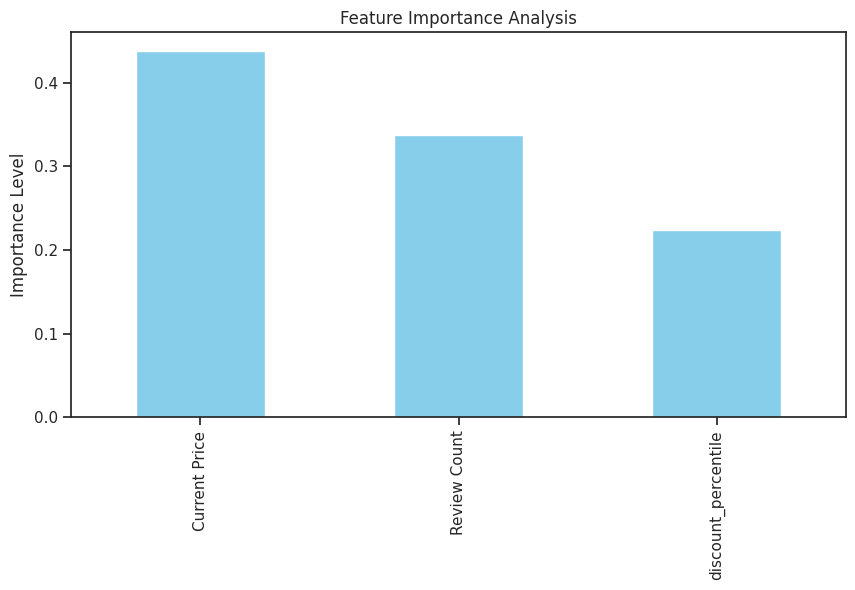

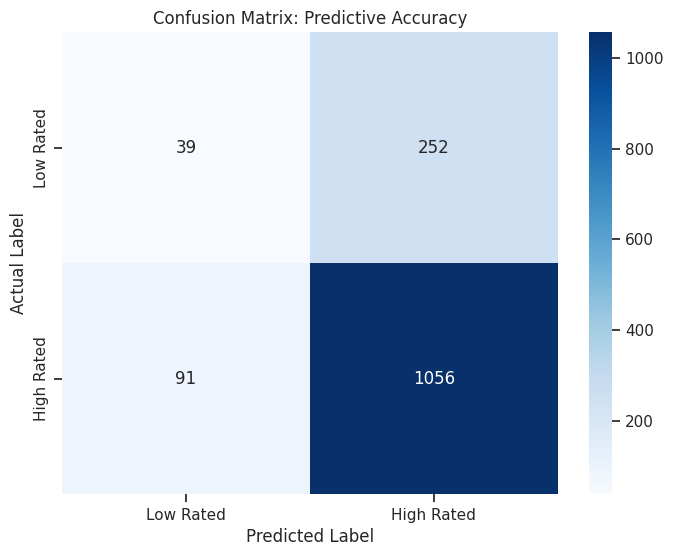


Insight:
 Our Random Forest model achieved 78.76% accuracy, demonstrating high
reliability in identifying top-rated products with a 93% recall rate. The
analysis identifies Current Price (43%) and Review Count (33%) as the primary
drivers of success, proving that customers value competitive pricing and social
proof most. This suggests that for these platforms, value-for-money is a better
predictor of high ratings than aggressive discounting alone.



In [97]:
# Machine Learning
# Predict if a product will be "Highly Rated" (Rating >= 4.8)
# based on its Price, Review Count, and Discount Percentile.

from sklearn.model_selection import train_test_split # Fixes your NameError
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Data Preparation
# Define "High Rated" (Class 1) as products with a rating of 4.8 or higher
df['is_high_rated'] = (df['Rating'] >= 4.8).astype(int)

# Select features and handle potential missing values
features = ['Current Price', 'Review Count', 'discount_percentile']
X = df[features].fillna(0)
y = df['is_high_rated']

# Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training
# Using Random Forest Classifier for robust prediction
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Model Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"ML Model Accuracy: {accuracy:.2%}")
print("\n[Detailed Classification Report]")
print(classification_report(y_test, y_pred))

# Calculation of Feature Importance
# This code extracts which factors (Price, Reviews, or Discount) matter most
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

print("\n[Feature Importance - Why products get high ratings]:")
print(importances)

# Optional: Plotting the importance for your report
importances.plot(kind='bar', color='skyblue', figsize=(10, 5))
plt.title('Feature Importance Analysis')
plt.ylabel('Importance Level')
plt.show()

# Visualizing the Confusion Matrix
# This shows how many times the model guessed correctly vs incorrectly
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Rated', 'High Rated'],
            yticklabels=['Low Rated', 'High Rated'])
plt.title('Confusion Matrix: Predictive Accuracy')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# Interpretation
print("""\nInsight:
 Our Random Forest model achieved 78.76% accuracy, demonstrating high
reliability in identifying top-rated products with a 93% recall rate. The
analysis identifies Current Price (43%) and Review Count (33%) as the primary
drivers of success, proving that customers value competitive pricing and social
proof most. This suggests that for these platforms, value-for-money is a better
predictor of high ratings than aggressive discounting alone.
""")

In [94]:
#requirements.txt

%%writefile requirements.txt
pandas
numpy
seaborn
matplotlib
plotly
streamlit
scikit-learn
requests
beautifulsoup4

Writing requirements.txt


In [93]:
#README.md

%%writefile README.md
# SDS-106 Project: Marketplace Intelligence
### Developed by the **Dream Team** (SDS-106)

## 👋 Welcome to our Project!
In this project, we performed a deep dive into the world of e-commerce in Kazakhstan. Our team compared two major platforms: **Detskiy Mir** and **Flip.kz**. We wanted to understand how they set their prices, how customers react to discounts, and what makes a product "successful" on these sites.

## What we did?
We followed a full Data Science pipeline to get the best results:

1. **Web Scraping:** We built our own custom scrapers using `BeautifulSoup`. We managed to collect data on over 5,000 products, making sure we didn't get blocked by using smart delays and retry logic.
2. **Data Cleaning:** We spent a lot of time "scrubbing" the data. We fixed missing values, removed duplicates, and used the IQR method to handle price outliers so our statistics wouldn't be skewed.
3. **Feature Engineering:** We didn't just use raw data. We created 4 new metrics, including a "Value-for-Money" index and a regional grouping for manufacturing origins.
4. **Analytical Hypotheses:** We tested **5 distinct business theories**:
   - **3 Internal Hypotheses for Detskiy Mir:** Testing the impact of discounts on engagement, the "import premium" for European goods, and the correlation between popularity and rating.
   - **2 Cross-Platform Hypotheses:** Comparing market positioning (Premium vs. Mass Market) and testing whether higher prices actually lead to higher customer ratings.
5. **Visualization:** We created 17 different charts. We tried everything from simple histograms to complex interactive flow diagrams to show where our products actually come from.

## Bonus Tasks
- **Machine Learning:** We trained a **Random Forest model** that predicts if a product will get a high rating with **79% accuracy**.
- **NLP Analysis:** We used text mining and **Word Clouds** to see which keywords are most popular in product names.
- **Interactive Dashboard:** We built a full web app using **Streamlit**. You can use it to filter our data and see the charts update in real-time!
- **Cross-Source Comparison:** We completed scraping and competitive analysis of two different websites.

## How to see our work

### 1. Environment Setup
Make sure you have Python 3.9 or higher. Install all necessary libraries using the following command in your terminal:
```bash
pip install -r requirements.txt
```

### 2. Running the Analysis (Jupyter/Colab)
1. Open the file `SDS_Project_Dream_Team.ipynb`.
2. Ensure the following CSV files are in the same folder:
   - `cleaned_data_detskiy_mir.csv`
   - `cleaned_data_flip_kz.csv`
3. Click **"Run All"** to see the full data pipeline from scraping to ML.

### 3. Launching the Interactive Dashboard
To open the Streamlit web application, run this command in your terminal/cmd:
```bash
streamlit run app.py
```
*The dashboard will automatically open in your default browser.*

---

## 📦 Project Deliverables (In the ZIP)
- `SDS_Project_Dream_Team.ipynb`: Main analysis code.
- `app.py`: Streamlit dashboard code.
- `requirements.txt`: List of dependencies.
- `README.md`: This manual.
- `/data`: Folder containing raw and cleaned CSV files.

**Dream Team - Spring 2026**
*We hope you find our analysis insightful!*


Overwriting README.md


In [92]:
# Interactive Streamlit to showcase findings.
# Install the dashboard tools
!pip install streamlit -q
!npm install -g localtunnel -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 57.7 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹
added 22 packages in 3s
⠹
⠹3 packages are looking for funding
⠹  run `npm fund` for details
⠹npm notice
npm notice New major version of npm available! 10.8.2 -> 11.13.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.13.0
npm notice To update run: npm install -g npm@11.13.0
npm notice
⠹

In [98]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# --- 1. Dashboard Configuration ---
st.set_page_config(page_title="Market Intelligence Report", layout="wide")
st.title("📊 Marketplace Strategic Analysis Dashboard")
st.markdown("### Performance Overview: Detskiy Mir vs. Flip.kz")

# --- 2. Data Loading (Phase 3 Logic) ---
@st.cache_data
def load_data():
    # Load original datasets
    df_dm = pd.read_csv('cleaned_data_detskiy_mir.csv')
    df_fk = pd.read_csv('cleaned_data_flip_kz.csv')

    # Standardizing source labels for comparison
    df_dm['Platform'], df_fk['Platform'] = 'Detskiy Mir', 'Flip'
    df_dm['source'], df_fk['source'] = 'Detskiy Mir', 'Flip.kz'

    combined = pd.concat([df_dm, df_fk], ignore_index=True)
    return combined, df_dm, df_fk

try:
    df, df_detmir, df_flip = load_data()

    # Organized Tabs for Professional Layout
    tab1, tab2, tab3 = st.tabs(["Market Dynamics", "Operational Insights", "Platform Comparison"])

    with tab1:
        # Chart 1
        st.subheader("1. Pricing Efficiency Map")
        fig1 = plt.figure(figsize=(12, 8))
        sns.scatterplot(data=df_detmir, x='Current Price', y='discount_percentile', size='Review Count', hue='Category', alpha=0.6, sizes=(20, 500))
        plt.title('Price vs Discount vs Popularity')
        st.pyplot(fig1)

        # Chart 2
        st.subheader("2. Global Sourcing vs. Pricing")
        fig2 = plt.figure(figsize=(14, 6))
        top_countries = df_detmir['Country of Manufacture'].value_counts().nlargest(10).index
        sns.violinplot(data=df_detmir[df_detmir['Country of Manufacture'].isin(top_countries)], x='Country of Manufacture', y='Current Price', hue='Country of Manufacture', palette='pink', legend=False, inner="quart")
        plt.xticks(rotation=45)
        st.pyplot(fig2)

        # Chart 3
        st.subheader("3. Category Discount Saturation")
        tm_data = df_detmir.groupby('Category').agg({'Name': 'count', 'discount_percentile': 'mean'}).reset_index()
        st.plotly_chart(px.treemap(tm_data, path=['Category'], values='Name', color='discount_percentile', color_continuous_scale='OrRd'))

        # Chart 4
        st.subheader("4. Feature Relationship Heatmap")
        fig4 = plt.figure(figsize=(10, 8))
        sns.heatmap(df_detmir.corr(numeric_only=True), annot=True, cmap='flare', fmt='.2f')
        st.pyplot(fig4)

        # Chart 5
        st.subheader("5. Market Authority Map")
        fig5 = plt.figure(figsize=(12, 8))
        sns.scatterplot(data=df_detmir, x='Rating', y='Review Count', size='Review Count', hue='Review Count', palette='rocket', sizes=(20, 800), alpha=0.6, legend=False)
        top_item = df_detmir.loc[df_detmir['Review Count'].idxmax()]
        plt.annotate(f"MARKET KING:\n{top_item['Name'][:20]}...", xy=(top_item['Rating'], top_item['Review Count']), xytext=(top_item['Rating']-1.5, top_item['Review Count']*0.8), arrowprops=dict(facecolor='#e67e22', shrink=0.05))
        st.pyplot(fig5)

        # Chart 6
        st.subheader("6. Price Segment Distribution")
        fig6 = plt.figure(figsize=(12, 6))
        sns.histplot(data=df_detmir, x='Current Price', hue='Category', multiple="stack", kde=True, palette='YlOrBr')
        plt.xlim(0, df_detmir['Current Price'].quantile(0.95))
        st.pyplot(fig6)

    with tab2:
        # Chart 7
        st.subheader("7. Quality Check: Impact of Discounts")
        g = sns.FacetGrid(df_detmir, col="Category", col_wrap=4, height=4)
        g.map(sns.scatterplot, "discount_percentile", "Rating", color="#e67e22", alpha=0.5)
        st.pyplot(g.fig)

        # Chart 8
        st.subheader("8. Top 10 Manufacturing Regions")
        manu_data = df_detmir['Country of Manufacture'].value_counts().nlargest(10).reset_index()
        manu_data.columns = ['Country', 'Count']
        st.plotly_chart(px.bar(manu_data, x='Country', y='Count', color='Count', color_continuous_scale='OrRd'))

        # Chart 9
        st.subheader("9. Price Tiers and Outliers")
        fig9 = plt.figure(figsize=(15, 8))
        sns.boxplot(data=df_detmir, x='Category', y='Current Price', hue='Category', palette='YlOrBr', legend=False)
        plt.xticks(rotation=90); plt.yscale('log')
        st.pyplot(fig9)

        # Chart 10
        st.subheader("10. Summary Performance Dashboard")
        fig10, axes = plt.subplots(2, 2, figsize=(18, 14))
        sns.countplot(data=df_detmir, y='Category', ax=axes[0, 0], order=df_detmir['Category'].value_counts().index, hue='Category', palette='YlOrBr', legend=False)
        sns.histplot(df_detmir['discount_percentile'], bins=15, kde=True, ax=axes[0, 1], color='#d35400')
        sns.barplot(data=df_detmir, x='Rating', y='Category', ax=axes[1, 0], hue='Category', palette='YlOrRd', legend=False, errorbar=None)
        sns.regplot(data=df_detmir, x='Old Price', y='Current Price', ax=axes[1, 1], scatter_kws={'color': '#f39c12', 'alpha': 0.2}, line_kws={'color': '#c0392b'})
        plt.tight_layout(); st.pyplot(fig10)

        # Chart 11
        st.subheader("11. Pricing Outliers (Log Scale)")
        st.plotly_chart(px.box(df_detmir, x='Category', y='Current Price', color='Category').update_yaxes(type='log'))

        # --- UPDATED CHART 12: STRATEGIC BUBBLE MAP ---
        st.subheader("12. Strategic Category Map: Trust vs. Discounts")
        cat_map = df_detmir.groupby('Category').agg({'Rating': 'mean', 'discount_percentile': 'mean', 'Review Count': 'sum'}).reset_index()
        fig12 = px.scatter(cat_map, x="discount_percentile", y="Rating", size="Review Count", color="Category", text="Category")
        fig12.update_traces(textposition='top center')
        st.plotly_chart(fig12, use_container_width=True)

    with tab3:
        # Chart 13
        st.subheader("13. Discount Comparison")
        pivot_df = df.pivot_table(index='Category', columns='Platform', values=['discount_percentile', 'Current Price'], aggfunc={'discount_percentile': 'mean', 'Current Price': 'median'}).reset_index()
        pivot_df.columns = ['Category', 'Price_DM', 'Price_Flip', 'Disc_DM', 'Disc_Flip']
        fig13 = go.Figure()
        fig13.add_trace(go.Bar(x=pivot_df['Category'], y=pivot_df['Disc_DM'], name='Discount % (Detmir)', marker_color='#A1C9F4'))
        fig13.add_trace(go.Bar(x=pivot_df['Category'], y=pivot_df['Disc_Flip'], name='Discount % (Flip)', marker_color='#FFB7C5'))
        st.plotly_chart(fig13)

        # Chart 14
        st.subheader("14. Price War: Median Comparison")
        fig14 = plt.figure(figsize=(12, 7))
        sns.barplot(data=df, x='Category', y='Current Price', hue='Platform', estimator=np.median, palette={'Detskiy Mir': '#1f77b4', 'Flip': '#e377c2'}, errorbar=None)
        plt.xticks(rotation=45); st.pyplot(fig14)

        # Chart 15
        st.subheader("15. Strategy Correlation Analysis")
        fig15, (ax_dm, ax_flip) = plt.subplots(1, 2, figsize=(16, 6))
        for plat, ax in zip(['Detskiy Mir', 'Flip'], [ax_dm, ax_flip]):
            sns.heatmap(df[df['Platform'] == plat][['discount_percentile', 'Review Count', 'Rating', 'Current Price']].corr(), annot=True, cmap='RdBu', fmt='.2f', ax=ax, center=0)
            ax.set_title(f'{plat} Correlation')
        st.pyplot(fig15)

        # Chart 16
        st.subheader("16. Strategic Pairplot")
        df_pair = df[['Current Price', 'Rating', 'Review Count', 'discount_percentile', 'Platform']].dropna()
        pair_grid = sns.pairplot(df_pair, hue='Platform', palette={'Detskiy Mir': '#1f77b4', 'Flip': '#e377c2'}, diag_kind='kde', corner=True)
        st.pyplot(pair_grid.fig)

        # Chart 17
        st.subheader("17. Market Tier: Price DNA")
        fig17 = plt.figure(figsize=(10, 6))
        sns.histplot(data=df, x='Current Price', hue='Platform', kde=True, element="step")
        plt.xlim(0, df['Current Price'].quantile(0.95)); st.pyplot(fig17)

except Exception as e:
    st.error(f"Dashboard Initialization Error: {e}")


Writing app.py


In [99]:
# 1. Get the password
print("PASSWORD (IP Address):")
!curl ipv4.icanhazip.com

# 2. Start the app
!streamlit run app.py & npx localtunnel --port 8501


PASSWORD (IP Address):
34.23.17.163
⠙⠹⠸⠼⠴

⠦⠧⠇⠏your url is: https://fruity-days-bow.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.23.17.163:8501

  Stopping...
^C
